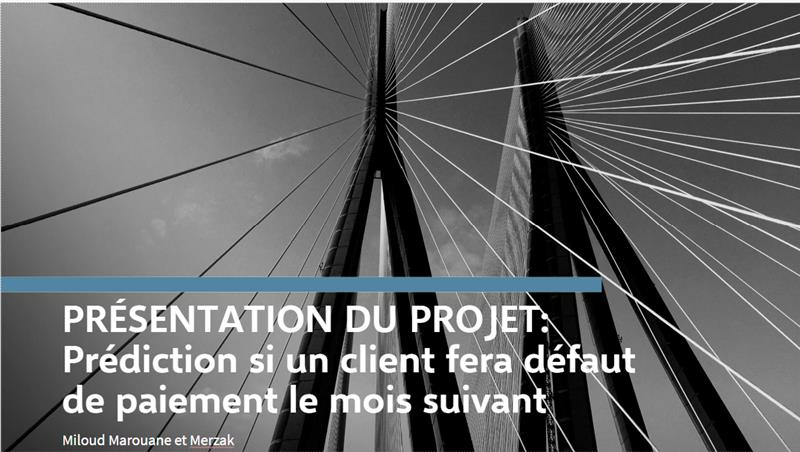

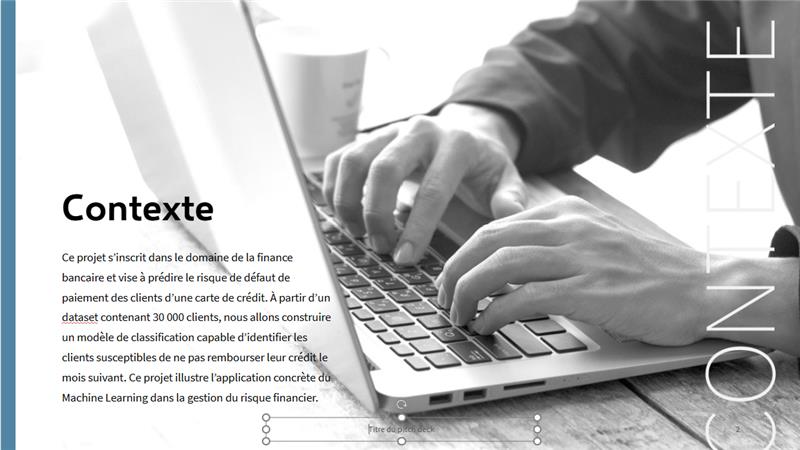

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

import warnings
warnings.filterwarnings("ignore")

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
# Pour un rendu plus joli des graphiques
sns.set_style("whitegrid")

# **1.Étapes du projet**

In [2]:
df = pd.read_csv('credit_card_clients.csv')
df.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
25419,25420,30000,Female,Niveau_2,Celibataire,27.0,0,0,0,0,0,0,4512,6628,9222,6368.0,1000,3070,2205.0,2111.0,2376,0.0,2070,1683,0
9865,9866,100000,Female,Niveau_3,Marié,50.0,0,0,0,0,0,2,36925,38324,39680,41687.0,43607,43739,2000.0,2000.0,2680,2600.0,1000,5261,1
21563,21564,30000,Female,Niveau_3,Celibataire,23.0,3,2,0,0,0,0,30051,29274,30498,29713.0,29819,30342,0.0,2000.0,1500,2000.0,1100,2000,0
1006,1007,200000,Female,Niveau_2,Celibataire,36.0,-1,-1,-1,-2,-2,-1,1371,4068,0,0.0,0,980,4077.0,0.0,0,0.0,980,0,0
23573,23574,300000,Female,Niveau_2,Marié,39.0,-2,-2,-2,-2,-2,-2,2022,537,142,656.0,620,502,537.0,142.0,656,620.0,502,142,0


### **a) Source et Domaine**
----------------------------------------------------------
   - **Source  :** UCI Machine Learning Repository
   - **Domaine :** Finance / Bancaire
--------------------------------------------------------
- **Ce dataset contient des informations sur des clients Taïwanais par carte de crédit.**

### **b)	Taille du dataset (nombre de lignes, colonnes).**

In [3]:
df.shape

(30000, 25)

-----------------------------------------------------------------------
**Le Dataset presente 30.000 lignes et 25 colonnes**

-----------------------------------------------------------------------

### **c)	Description des variables (types, rôle des features, cible).**

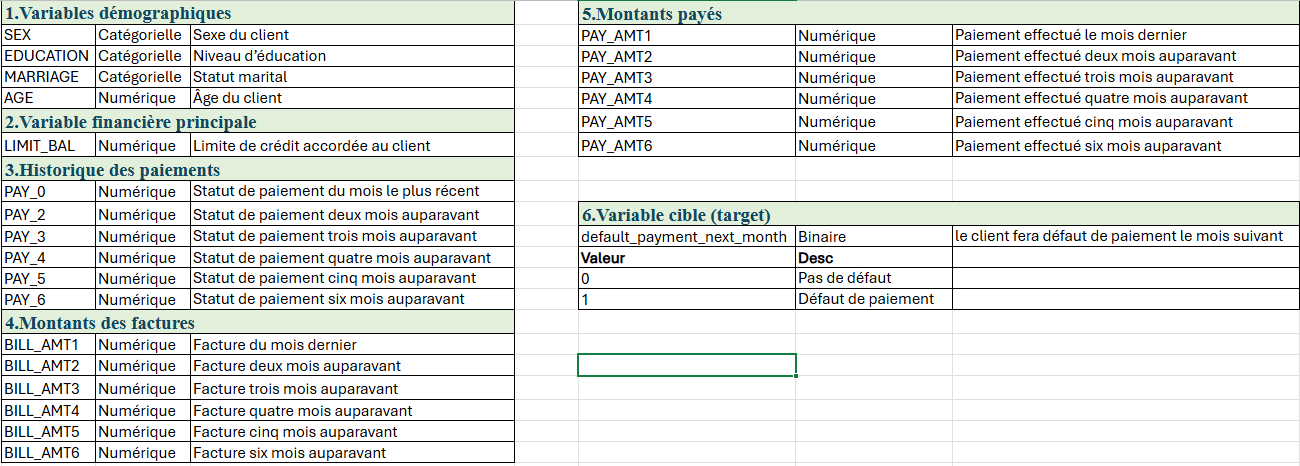

### **d)	Finalité du problème : classification ou régression.**

==================================================
- **Finalité du problème**
==================================================
   - La variable cible **'default_payment_next_month'** est binaire (0 ou 1).**
   - L'objectif est de prédire si un client fera défaut de paiement ou non.**
-------------------------------------------------------------------------------
- Il s'agit donc d'un problème de **CLASSIFICATION BINAIRE.**

# **2. Analyse exploratoire et diagnostic**

### **1.•	Détection des valeurs manquantes.**


- COLONNES AVEC VALEURS MANQUANTES
  Colonne  Valeurs_Manquantes  Pourcentage
      SEX                   5     0.016667
      AGE                   5     0.016667
BILL_AMT4                   4     0.013333
 PAY_AMT1                   1     0.003333
 PAY_AMT2                   1     0.003333
 PAY_AMT4                   1     0.003333


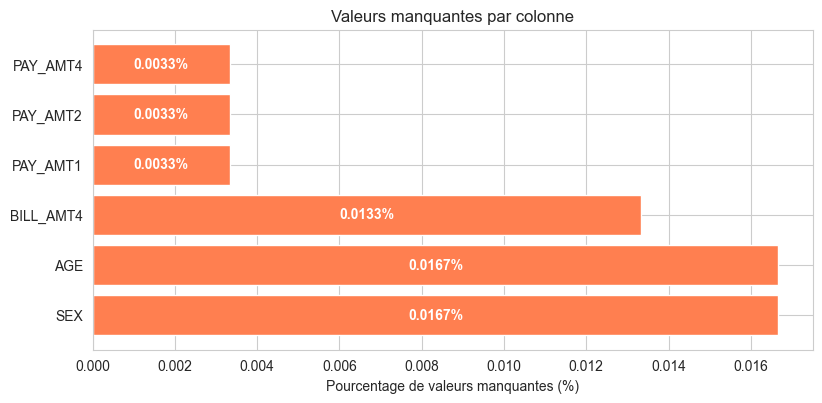

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔧 Désactiver complètement constrained_layout (important !)
plt.rcParams['figure.constrained_layout.use'] = False

# 1. Calculer les valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Valeurs_Manquantes': df.isnull().sum().values,
    'Pourcentage': (df.isnull().sum().values / len(df)) * 100
})

# 2. Filtrer et trier
missing_data = (
    missing_data[missing_data['Valeurs_Manquantes'] > 0]
    .sort_values('Pourcentage', ascending=False)
)

# 3. Afficher le tableau
print("\n- COLONNES AVEC VALEURS MANQUANTES")
print(missing_data.to_string(index=False))

# 4. Graphique — version stable sans tight_layout ni constrained_layout
fig, ax = plt.subplots(figsize=(12, max(4, len(missing_data) * 0.5)))

bars = ax.barh(
    missing_data['Colonne'],
    missing_data['Pourcentage'],
    color='coral'
)

ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
ax.set_title('Valeurs manquantes par colonne')

# 5. Ajouter les pourcentages en gras à l'intérieur des barres
for bar, pct in zip(bars, missing_data['Pourcentage']):
    ax.text(
        bar.get_width() / 2,                      # position X = milieu de la barre
        bar.get_y() + bar.get_height() / 2,       # position Y = milieu vertical
        f'{pct:.4f}%',                             # format adapté aux petites valeurs
        ha='center', va='center',
        color='white', fontsize=10, fontweight='bold'
    )

# 6. Ajustement manuel des marges (compatible à 100%)
plt.subplots_adjust(left=0.35, right=0.95, top=0.9, bottom=0.1)

plt.show()


### **2. Identification des valeurs aberrantes (outliers).**

In [5]:
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['default_payment_next_month','ID' ] ]
outlier_percent = {}
print("TABLEAU DES VALEURS ABERRANTES:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_percent[col] = (len(outliers) / len(df)) * 100

pd.DataFrame(outlier_percent.items(), 
             columns=["Variable", "Pourcentage_outliers"]).sort_values(by="Pourcentage_outliers", ascending=False)

TABLEAU DES VALEURS ABERRANTES:


,Variable,Pourcentage_outliers
3,PAY_2,14.700000
4,PAY_3,14.030000
5,PAY_4,11.693333
2,PAY_0,10.433333
7,PAY_6,10.263333
17,PAY_AMT4,9.980000
6,PAY_5,9.893333
19,PAY_AMT6,9.860000
18,PAY_AMT5,9.816667
14,PAY_AMT1,9.150000


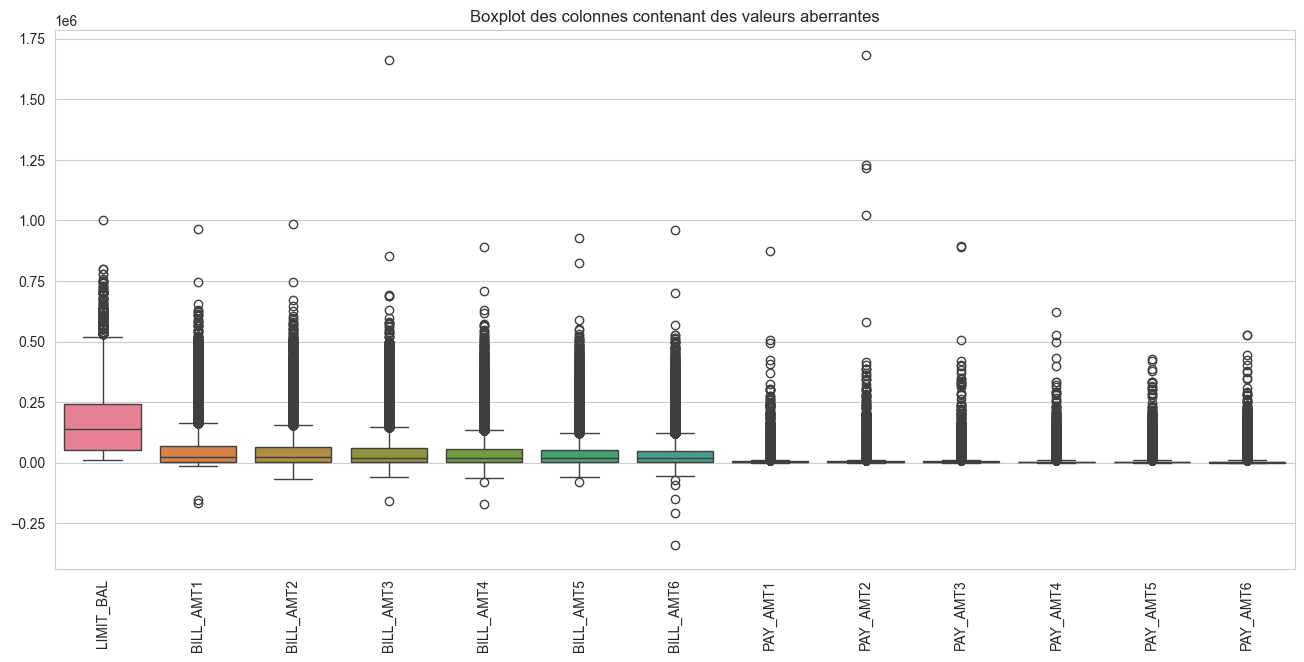

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# colonnes numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns

# colonnes à exclure (catégorielles ou discrètes)
exclude_cols = ["ID","SEX","EDUCATION","MARRIAGE","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6","AGE","default_payment_next_month"]

outlier_cols = []

for col in num_cols:
    
    if col in exclude_cols:
        continue
        
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    if ((df[col] < lower) | (df[col] > upper)).any():
        outlier_cols.append(col)

# graphe moustache
plt.figure(figsize=(16,7))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=90)
plt.title("Boxplot des colonnes contenant des valeurs aberrantes")
plt.show()

### **3. Vérification du déséquilibre de classes (si classification).**

Distribution de la variable cible 'default_payment_next_month':
Classe 0 (Non-défaut): 23364 clients (77.88%)
Classe 1 (Défaut): 6636 clients (22.12%)
Total: 30000 clients


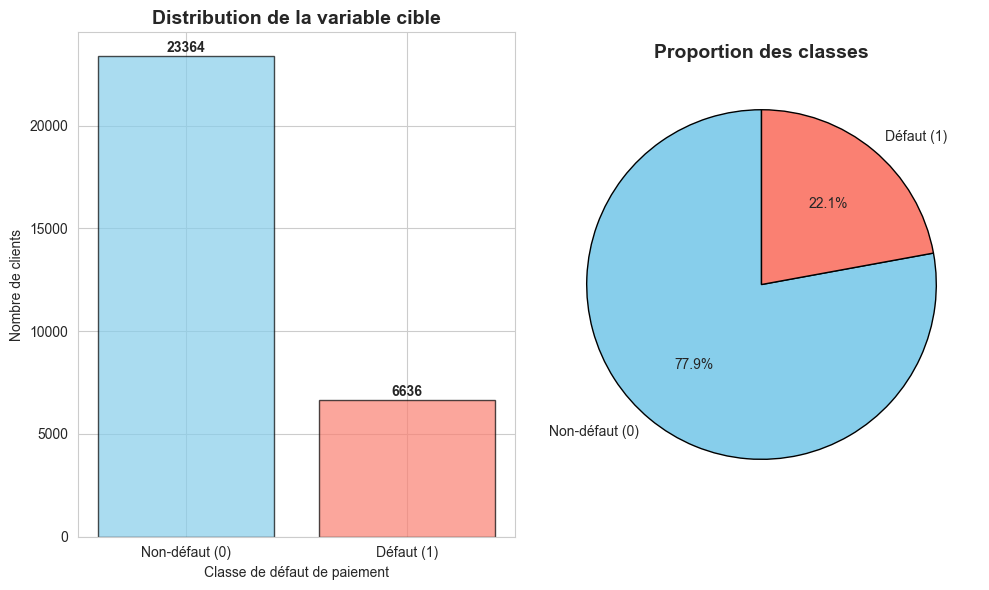


ANALYSE DU DÉSÉQUILIBRE DES CLASSES
  Déséquilibre détecté ! Ratio classe majoritaire / minoritaire : 3.52 (1)
   La classe majoritaire représente 77.9% des données
   Il faudra prendre en compte ce déséquilibre lors de la modélisation
   (techniques de rééchantillonnage, métriques adaptées, etc.)


In [7]:
# Compter les valeurs de la variable cible
class_counts = df['default_payment_next_month'].value_counts().sort_index()
 
# Afficher les statistiques
print("Distribution de la variable cible 'default_payment_next_month':")
print(f"Classe 0 (Non-défaut): {class_counts[0]} clients ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Classe 1 (Défaut): {class_counts[1]} clients ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Total: {len(df)} clients")
 
# Créer l'histogramme
plt.figure(figsize=(10, 6))
 
# Version avec barres
plt.subplot(1, 2, 1)
bars = plt.bar(['Non-défaut (0)', 'Défaut (1)'], class_counts.values, 
               color=['skyblue', 'salmon'], edgecolor='black', alpha=0.7)
plt.title('Distribution de la variable cible', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de clients')
plt.xlabel('Classe de défaut de paiement')
 
# Ajouter les valeurs sur les barres
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count}', ha='center', va='bottom', fontweight='bold')
 
# Version camembert
plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=['Non-défaut (0)', 'Défaut (1)'], 
        autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Proportion des classes', fontsize=14, fontweight='bold')
 
plt.tight_layout()
plt.show()
 
# Vérification du déséquilibre des classes
print("\n" + "="*50)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("="*50)
if class_counts[0] > class_counts[1] * 1.5:
    ratio = class_counts[0] / class_counts[1]
    print(f"  Déséquilibre détecté ! Ratio classe majoritaire / minoritaire : {ratio:.2f} (1)")
    print(f"   La classe majoritaire représente {class_counts[0]/len(df)*100:.1f}% des données")
    print("   Il faudra prendre en compte ce déséquilibre lors de la modélisation")
    print("   (techniques de rééchantillonnage, métriques adaptées, etc.)")
else:
    print(" Les classes sont relativement équilibrées")

### **4. Corrélations entre variables (multicolinéarité).**

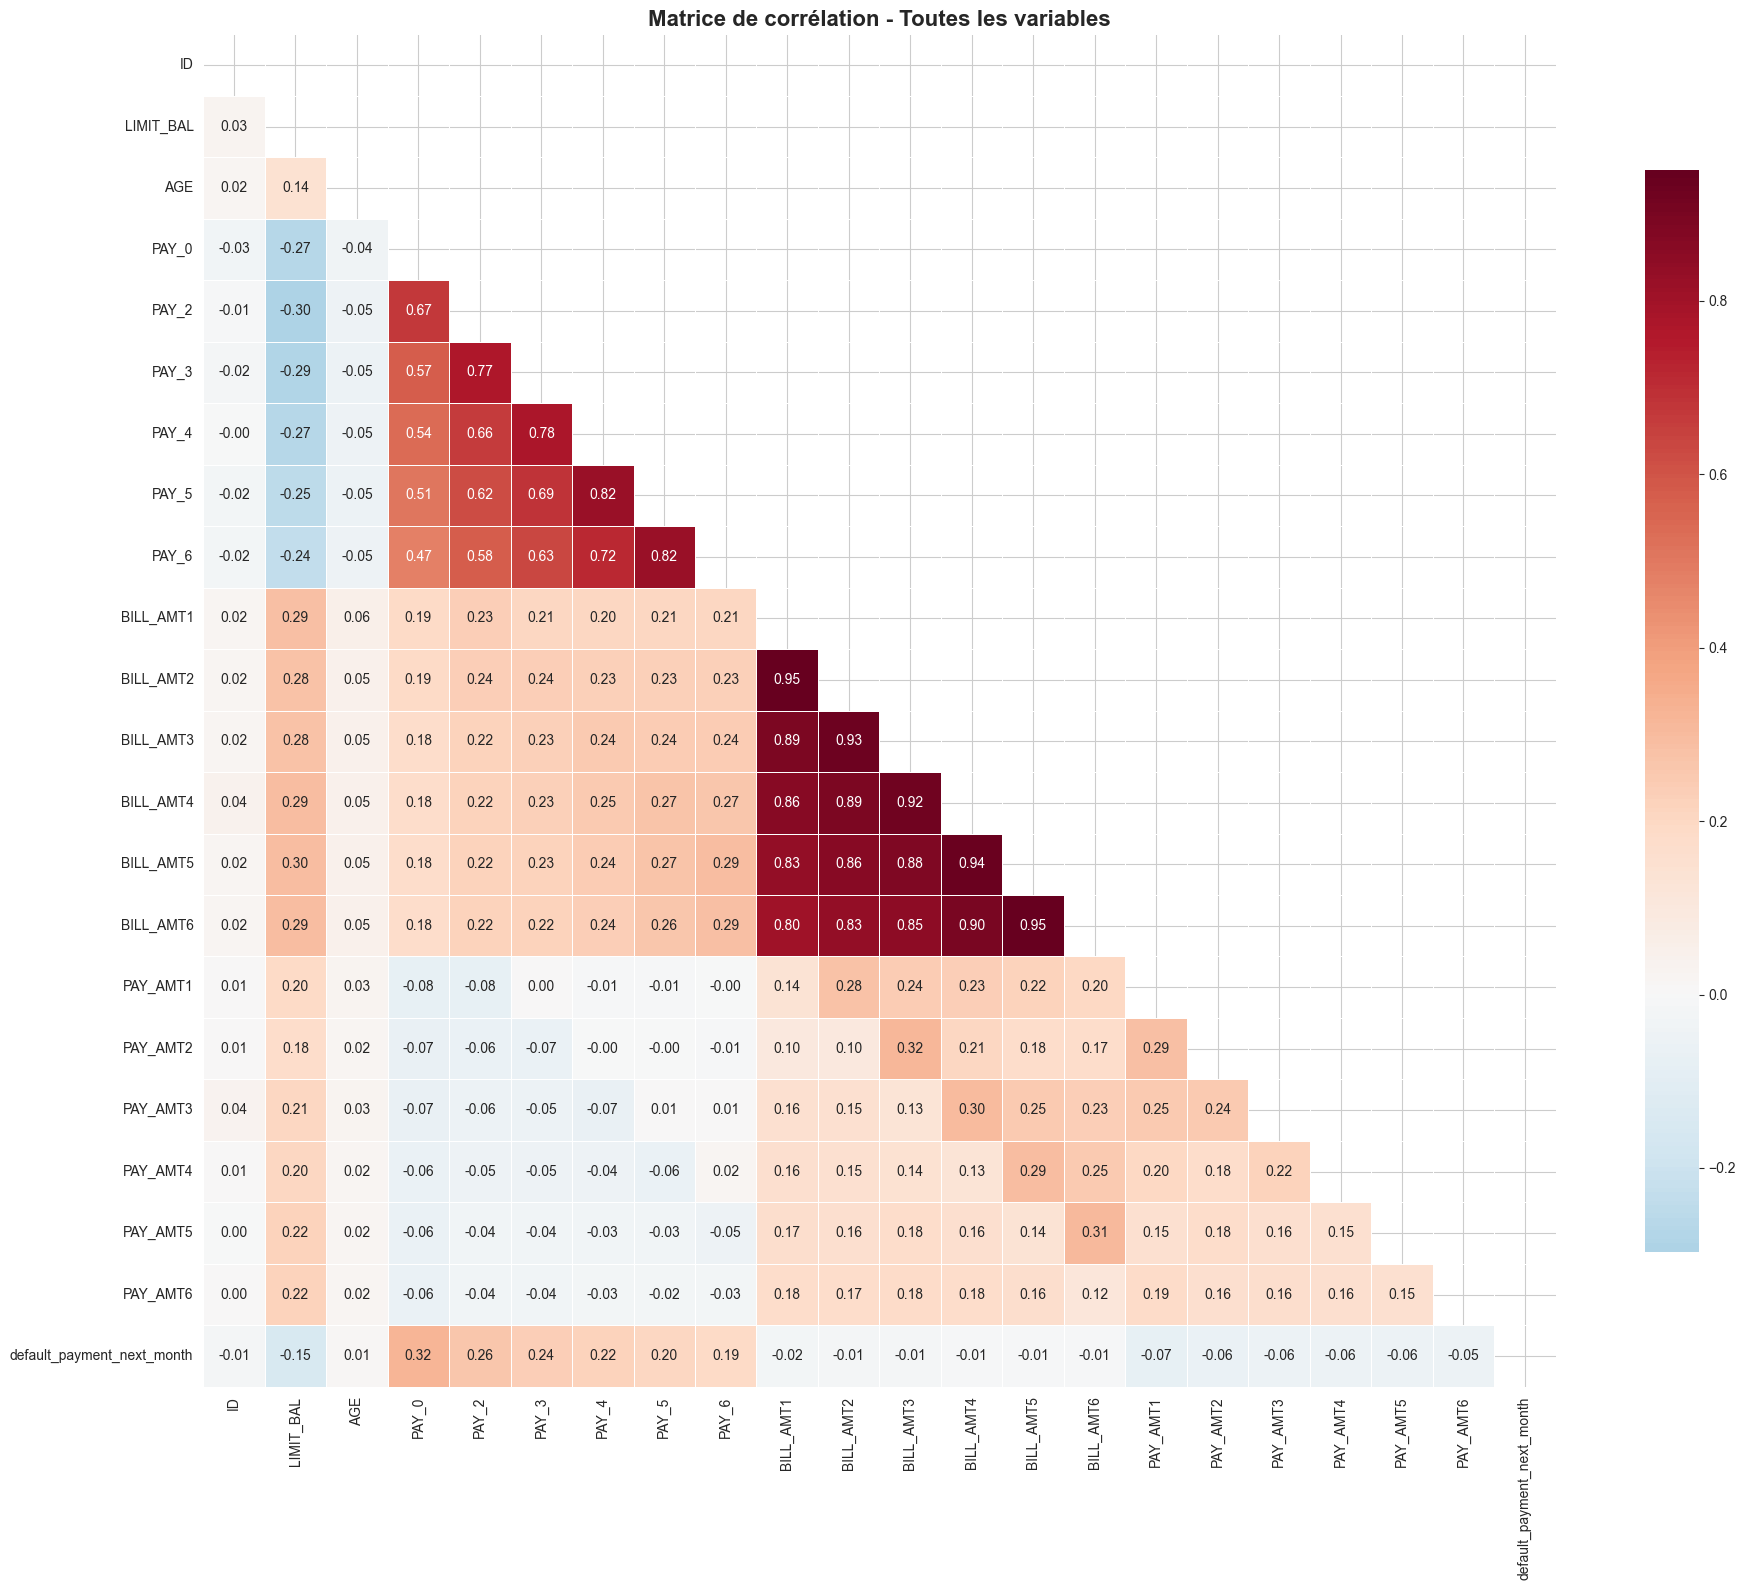

In [8]:
# Sélectionner les colonnes numériques (exclure l'ID et les colonnes non pertinentes)
#cols_to_exclude = ['ID', 'random_noise', 'LIMIT_BAL_copy']
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns ]
 
# Calculer la matrice de corrélation
corr_matrix = df[numeric_cols].corr()

# 1. HEATMAP DE CORRÉLATION COMPLÈTE
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masquer la partie supérieure
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation - Toutes les variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


CORRÉLATIONS AVEC LA VARIABLE CIBLE 'default_payment_next_month'

Top 10 variables corrélées positivement avec le défaut :
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
AGE          0.013392
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010186

Top 10 variables corrélées négativement avec le défaut :
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058581
PAY_AMT1    -0.072931
LIMIT_BAL   -0.153520


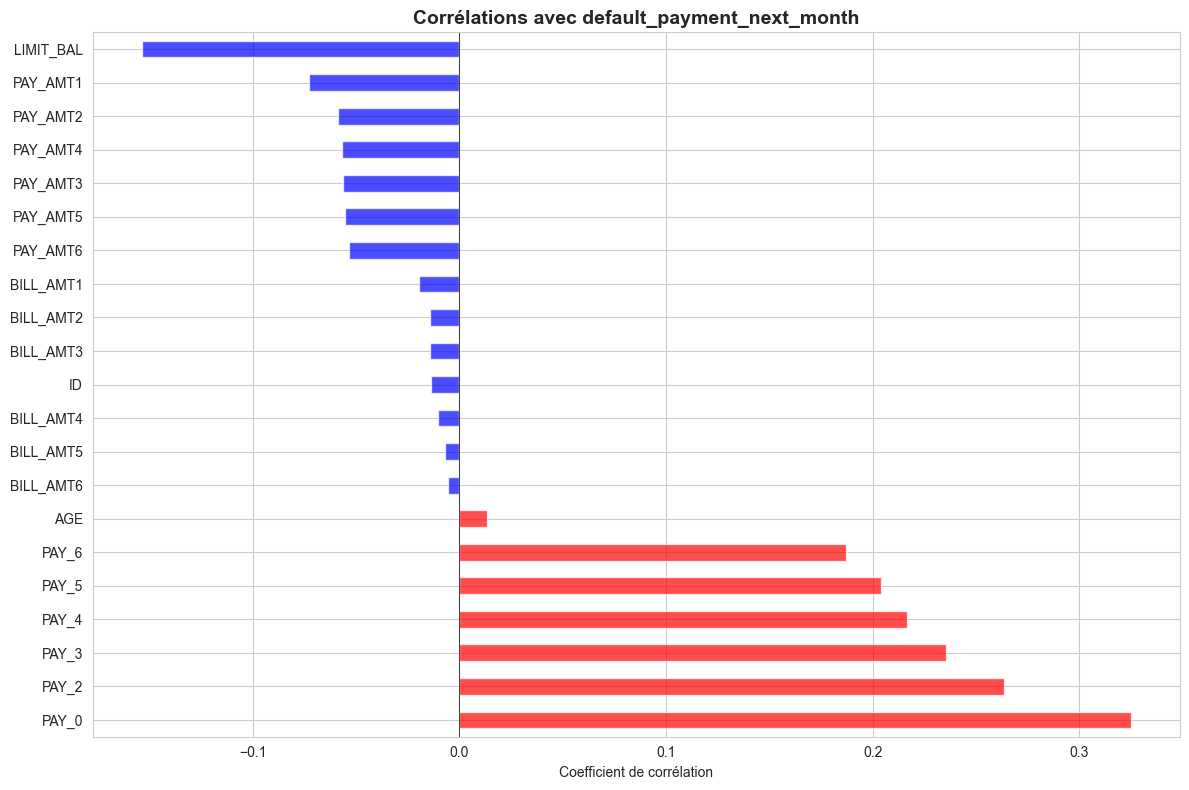

In [9]:
# 3. CORRÉLATIONS AVEC LA VARIABLE CIBLE
print("\n" + "=" * 70)
print("CORRÉLATIONS AVEC LA VARIABLE CIBLE 'default_payment_next_month'")
print("=" * 70)
 
target_corr = corr_matrix['default_payment_next_month'].drop('default_payment_next_month')
target_corr_sorted = target_corr.sort_values(ascending=False)
 
print("\nTop 10 variables corrélées positivement avec le défaut :")
print(target_corr_sorted.head(10).to_string())
 
print("\nTop 10 variables corrélées négativement avec le défaut :")
print(target_corr_sorted.tail(10).to_string())
 
# Visualisation des corrélations avec la cible
plt.figure(figsize=(12, 8))
colors = ['red' if x > 0 else 'blue' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Corrélations avec default_payment_next_month', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient de corrélation')
plt.tight_layout()
plt.show()

### **5. Distribution statistique des features (numériques/catégorielles)**

**1. numériques**

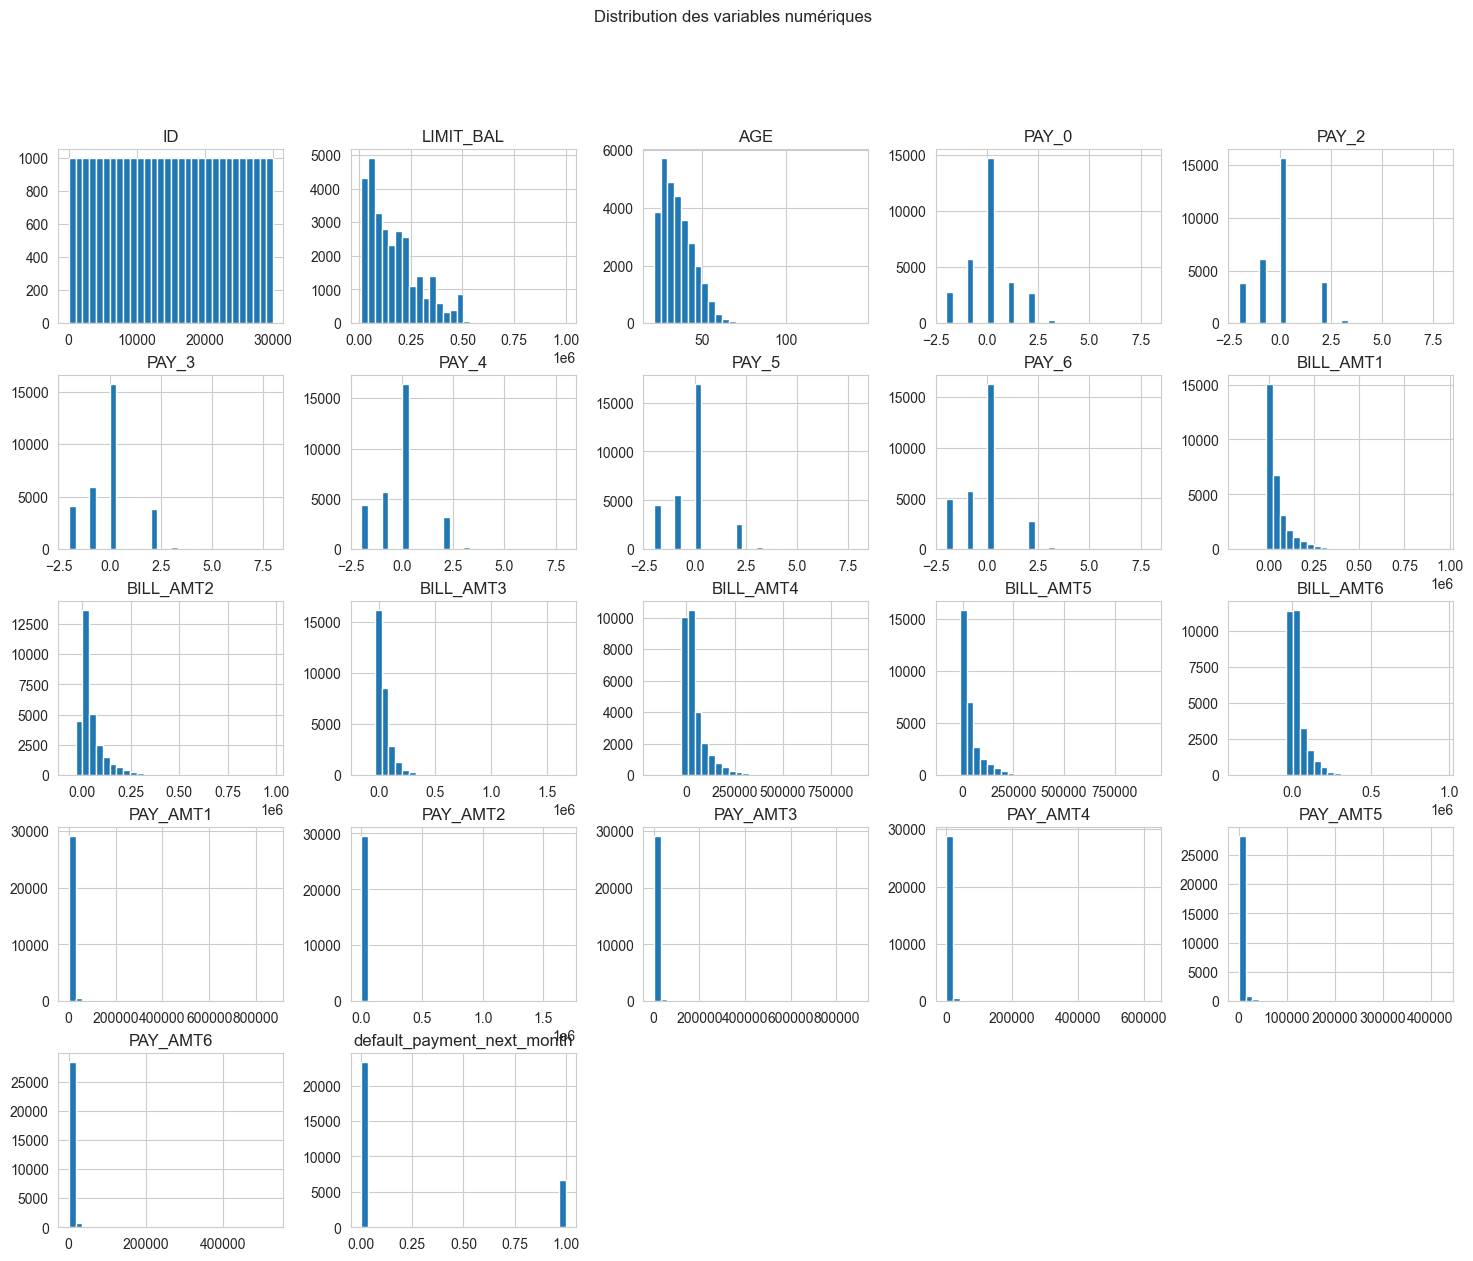

In [10]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(18,14), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.show()

**2. catégorielles**


Distribution de SEX
SEX
Female    60.373396
Male      39.626604
Name: proportion, dtype: float64

Distribution de EDUCATION
EDUCATION
Niveau_2    46.766667
Niveau_1    35.283333
Niveau_3    16.390000
Niveau_5     0.933333
Niveau_4     0.410000
Niveau_6     0.170000
Niveau_0     0.046667
Name: proportion, dtype: float64

Distribution de MARRIAGE
MARRIAGE
Celibataire    53.213333
Marié          45.530000
Autres          1.076667
Divorcé         0.180000
Name: proportion, dtype: float64


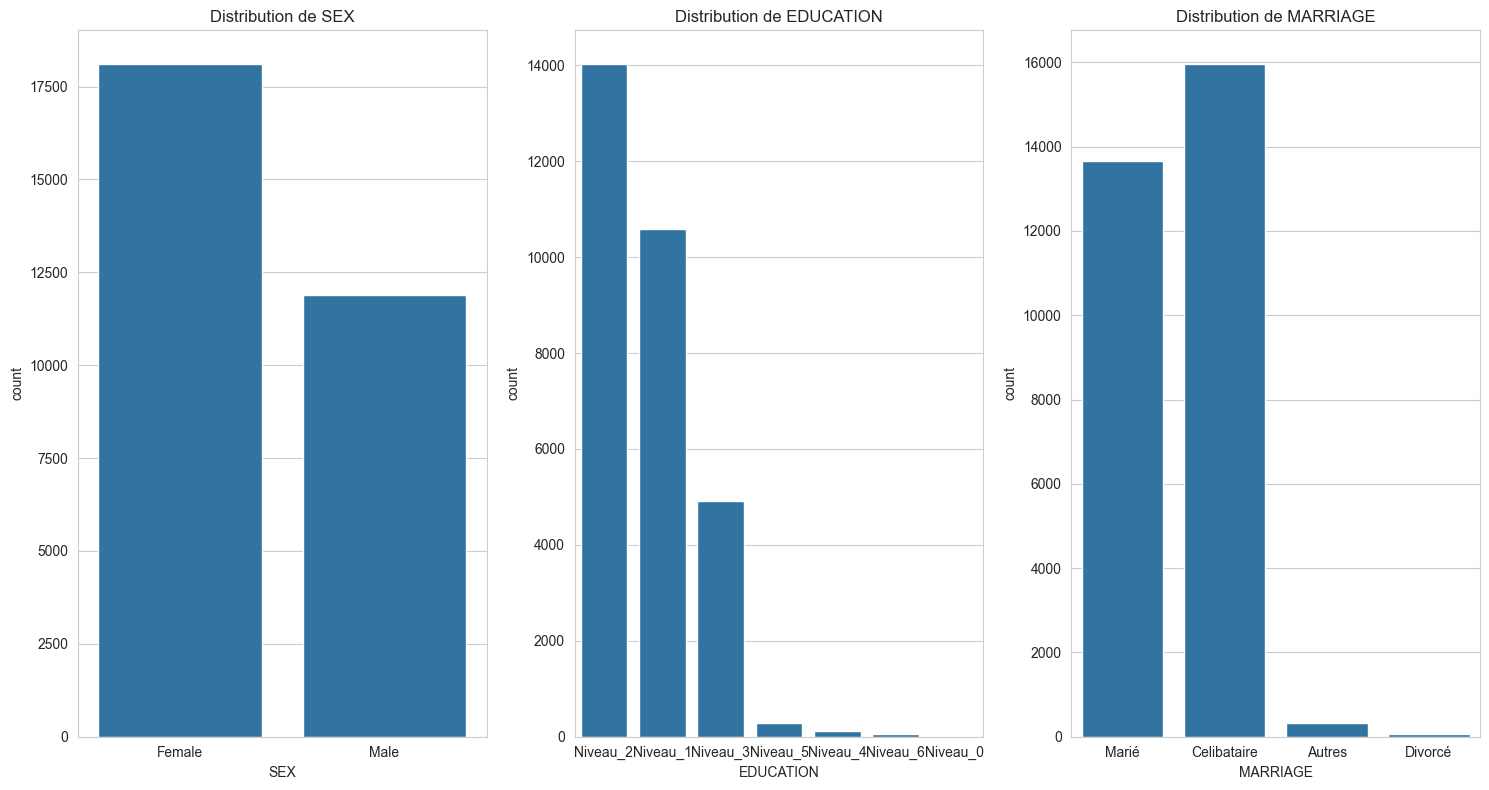

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns
 
for col in cat_cols:
    print(f"\nDistribution de {col}")
    print(df[col].value_counts(normalize=True) * 100)
    

plt.figure(figsize=(15,8))
 
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution de {col}")
 
plt.tight_layout()
plt.show()

### **3. Préparation et nettoyage**

### **1. Imputation des valeurs manquantes (moyenne, médiane, KNN, etc.).**

In [12]:

#num_cols = df.select_dtypes(include=['int64','float64']).columns
 
# imputation numérique avec médiane
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
 
# imputation catégoriel avec mode
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [13]:
df.isnull().sum().sum()

np.int64(0)

### **2 .	Traitement des outliers (suppression, winsorisation, transformation).**

- certaines valeurs qui ressemblent à des outliers ne sont pas forcément des erreurs. Par exemple 
  - LIMIT_BAL élevé → client riche
  - BILL_AMT élevé → grosse facture
  - PAY_AMT élevé → gros paiement
----------------------------------------------------
- Donc on ne doit pas supprimer tous les outliers automatiquement.
On va appliquer une méthode intelligente :
  - détecter les outliers
  - analyser s’ils sont plausibles
  - appliquer une transformation ou winsorisation si nécessaire

**Détection des outliers avec la méthode IQR**

In [14]:
num_cols = [
    'LIMIT_BAL','AGE',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]
 
outliers = {}
 
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]
 
pd.DataFrame.from_dict(outliers, orient='index', columns=['Nb_outliers'])

,Nb_outliers
LIMIT_BAL,167
AGE,274
BILL_AMT1,2400
BILL_AMT2,2395
BILL_AMT3,2469
BILL_AMT4,2622
BILL_AMT5,2725
BILL_AMT6,2693
PAY_AMT1,2745
PAY_AMT2,2714


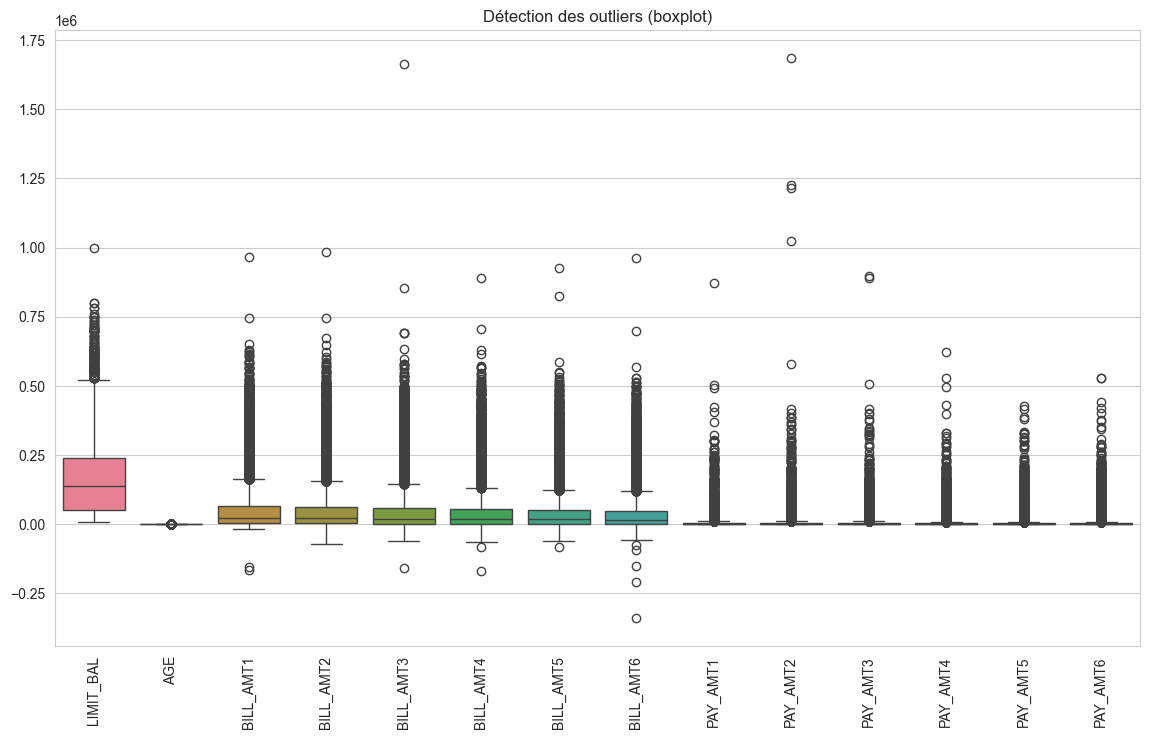

In [15]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Détection des outliers (boxplot)")
plt.show()

- Analyse importante :
   - beaucoup d’outliers apparaissent dans
      - **BILL_AMT**
      - **PAY_AMT**
      - **LIMIT_BAL**
------------------------------------------------------------------------
- Mais ces valeurs représentent souvent de vrais comportements financiers.
Donc :
   - supprimer ces lignes : **mauvaise idée**
   - transformer les variables : **meilleure solution**
----------------------------------------------------------------------
- Solution recommandée : **transformation logarithmique*** ou **Winsorisation**

**Transformation avec Winsorisation**

In [16]:
#log_cols = [
#'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
#'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
#]
 
from scipy.stats.mstats import winsorize
 
for col in num_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

- Cela limite les valeurs aux 1% extrêmes
- L’utilisation de la Winsorisation a permis de **réduire l’impact des valeurs aberrantes tout en conservant l’information contenue dans les données**. Cette étape améliore la qualité des données et prépare le dataset pour les étapes suivantes de modélisation en machine learning.
- La Winsorisation est souvent préférée dans les datasets financiers, car elle permet de traiter les valeurs extrêmes sans supprimer des observations potentiellement importantes.

In [17]:
num_cols = [
    'LIMIT_BAL','AGE',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]
 
outliers = {}
 
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]
 
pd.DataFrame.from_dict(outliers, orient='index', columns=['Nb_outliers'])

,Nb_outliers
LIMIT_BAL,0
AGE,0
BILL_AMT1,2398
BILL_AMT2,2395
BILL_AMT3,2468
BILL_AMT4,2620
BILL_AMT5,2724
BILL_AMT6,2688
PAY_AMT1,2745
PAY_AMT2,2714


Outlayer apres application du Winsorisation....


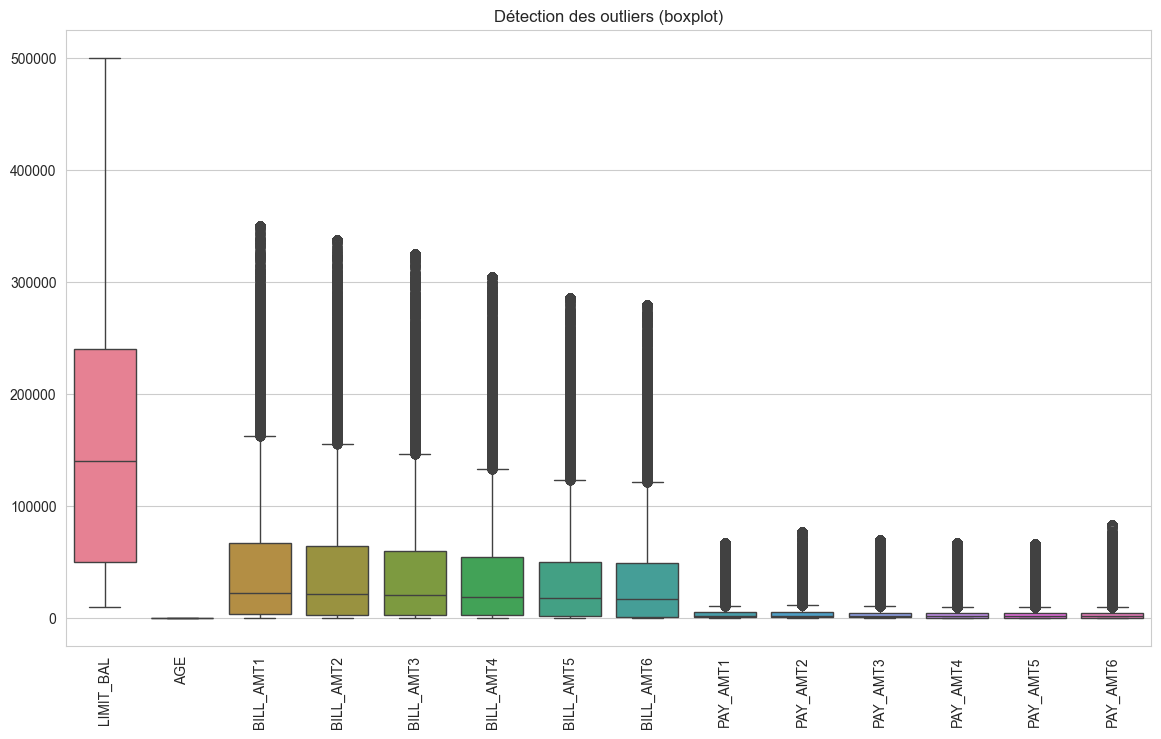

In [18]:
print('Outlayer apres application du Winsorisation....')
plt.figure(figsize=(14,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Détection des outliers (boxplot)")
plt.show()

### **3 Normalisation / standardisation des données.**

- **Standardisation** (StandardScaler)
   - Centre les données autour de **0** avec écart-type **1**
   - C'est la méthode la plus utilisée en ML.

In [19]:
from sklearn.preprocessing import StandardScaler
 
# Colonnes numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns.difference(
    ['default_payment_next_month']
)

df_scaled = df.copy() 

# Initialiser le scaler
scaler = StandardScaler()

# Appliquer la standardisation
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print(num_cols)
df_scaled.sample(2)


Index(['AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
       'BILL_AMT6', 'ID', 'LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
3039,-1.381080,0.025014,Male,Niveau_1,Celibataire,0.390609,0.014861,0.111736,0.138865,0.188746,0.234917,0.253137,1.742145,2.087850,1.941248,1.589989,1.797984,1.827563,0.845228,0.103014,1.092514,0.189136,0.308934,0.040416,0
3582,-1.318379,0.652060,Female,Niveau_2,Marié,-0.379309,0.014861,0.111736,-1.532192,-1.521944,-1.530046,-1.486041,-0.151324,-0.474753,-0.453393,-0.416454,-0.699508,-0.689441,0.385637,1.151609,1.354436,-0.457960,-0.463430,-0.412525,0


- Les variables numériques présentent des échelles très différentes, notamment les montants de crédit et de paiement. Afin d'éviter qu'une variable domine l'apprentissage du modèle, une standardisation a été appliquée à l'aide de la méthode **StandardScaler**.
- Cette transformation centre les données autour de **zéro** et leur attribue un écart-type égal à **un**, ce qui améliore la performance et la stabilité des algorithmes de machine learning.

### **4 Encodage des variables catégorielles (OneHot, Label Encoding).**

In [20]:
df_scaled['SEX'].unique()

array(['Female', 'Male'], dtype=object)

In [21]:
df_scaled['EDUCATION'].unique()

array(['Niveau_2', 'Niveau_1', 'Niveau_3', 'Niveau_5', 'Niveau_4',
       'Niveau_6', 'Niveau_0'], dtype=object)

In [22]:
df_scaled['MARRIAGE'].unique()

array(['Marié', 'Celibataire', 'Autres', 'Divorcé'], dtype=object)

In [23]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df_scaled[cat_cols])
encoded_df = pd.DataFrame(encoded, 
                          columns=encoder.get_feature_names_out(cat_cols))
X_final = pd.concat([df_scaled.drop(columns=cat_cols),
                     encoded_df], axis=1)
 

In [24]:
X_final.sample(5)

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month,SEX_Male,EDUCATION_Niveau_1,EDUCATION_Niveau_2,EDUCATION_Niveau_3,EDUCATION_Niveau_4,EDUCATION_Niveau_5,EDUCATION_Niveau_6,MARRIAGE_Celibataire,MARRIAGE_Divorcé,MARRIAGE_Marié
22447,0.859963,-0.915555,0.720574,0.014861,0.111736,0.138865,0.188746,0.234917,0.253137,-0.036885,-0.111426,-0.268935,0.037303,-0.212501,-0.163798,-0.312445,-0.314142,2.766135,-0.352591,-0.242424,-0.302551,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26526,1.330966,-0.837174,1.820457,0.014861,0.111736,0.138865,0.188746,1.999879,0.253137,0.141793,0.182697,0.234385,0.336166,0.375277,0.423839,-0.303537,-0.251965,0.159889,-0.457960,-0.249816,-0.244937,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
25920,1.260991,0.573679,-0.709274,0.014861,0.111736,0.138865,0.188746,0.234917,-1.486041,-0.474049,1.659345,1.619014,0.328589,-0.699508,-0.689441,6.519911,-0.086031,-0.338223,-0.190494,-0.463430,-0.412525,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25414,1.202563,0.495298,-0.489298,-0.874991,-0.723570,0.138865,0.188746,0.234917,0.253137,-0.580537,0.020906,0.046384,0.019267,0.048967,0.088402,4.745174,-0.201778,-0.331319,-0.295000,0.088258,-0.267584,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7311,-0.887792,-0.680413,-0.599286,0.014861,0.111736,0.138865,0.188746,0.234917,0.253137,-0.554767,-0.574391,-0.546880,-0.519356,-0.495052,-0.503494,-0.407671,-0.380187,-0.424205,-0.414820,-0.408261,0.040416,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **5 -	Échantillonnage ou équilibrage (SMOTE, undersampling, oversampling).**

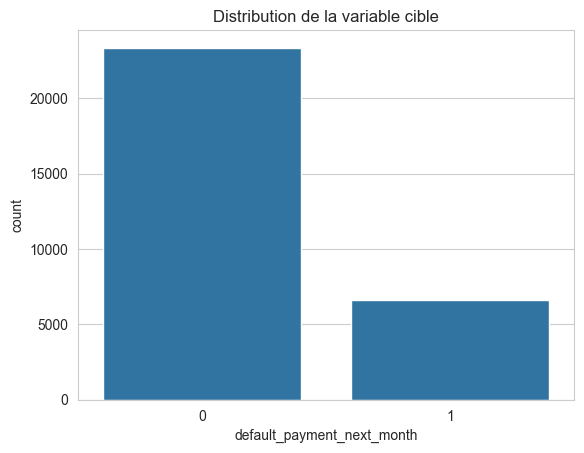

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
 
sns.countplot(x='default_payment_next_month', data=X_final)
plt.title("Distribution de la variable cible")
plt.show()

### ** Preparer X ,y

In [26]:
target_col = 'default_payment_next_month'
id_col='ID'
# 1. Séparer X et y
X = X_final.drop(columns=[target_col, id_col] if id_col in X_final.columns else [target_col])
y = X_final[target_col]

# **UDF Generique** 

### **Fonction permettant d'appliquer le balancement sur différentes approches**
  - **prepare_balanced_data**(
      - X,y,
      - test_size=0.2,
      - random_state=42,
      - method='smote'   # options: 'smote', 'undersample', 'both', 'none'

In [27]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import pandas as pd
 
def prepare_balanced_data(
    X,y,
    test_size=0.2,
    random_state=42,
    method='smote'   # options: 'smote', 'undersample', 'both', 'none'
):
    print("\n==============================")
    print("Préparation des données")
    print("================================")
    
    print(f"\nDimensions: X={X.shape}, y={y.shape}")
    print(f"Classe 0: {(y==0).sum()} | Classe 1: {(y==1).sum()}")
    print('\n---------------------------------------------------')

    # 2. Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

    print('\n---------------------------------------------------')

    # 3. Choisir la méthode d'équilibrage
    X_res, y_res = X_train, y_train
    if method == 'smote':
        print("Application SMOTE ")
        sampler = SMOTE(random_state=random_state, k_neighbors=5)
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    elif method == 'undersample':
        print("Application RandomUnderSampler")
        sampler = RandomUnderSampler(random_state=random_state)
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    elif method == 'both':
        print("Application SMOTE + Undersampling")
        over = SMOTE(random_state=random_state)
        under = RandomUnderSampler(random_state=random_state)
        pipeline = Pipeline([
            ('o', over),
            ('u', under)
        ])
        X_res, y_res = pipeline.fit_resample(X_train, y_train)
    elif method == 'none':
        print("Aucun équilibrage appliqué")
    print('\n---------------------------------------------------')
    # Tableau comparatif
    comp = pd.DataFrame({
        'Métrique': ['Observations', 'Classe 0', 'Classe 1', 'Ratio'],
        'Avant': [
            f"{len(X_train):,}",
            f"{(y_train==0).sum():,}",
            f"{(y_train==1).sum():,}",
            f"{(y_train==0).sum()/(y_train==1).sum():.2f}:1"
        ],
        'Après': [
            f"{len(X_res):,}",
            f"{(y_res==0).sum():,}",
            f"{(y_res==1).sum():,}",
            f"{(y_res==0).sum()/(y_res==1).sum():.2f}:1"
        ]
    })
    display(comp)

    return X_train, X_test, y_train, y_test, X_res, y_res
 

### **Fonction pour afficher la distribution de la classe balancée**
- **plot_class_distribution**(
   - y_before,
   - y_after,
   - title="Distribution des classes",
   - labels=("Non-Défaut", "Défaut"),
   - colors=('lightgreen', 'salmon')

In [28]:
def plot_class_distribution(
    y_before,
    y_after,
    title="Distribution des classes",
    labels=("Non-Défaut", "Défaut"),
    colors=('lightgreen', 'salmon')
):
    # Comptage
    before_counts = y_before.value_counts().sort_index()
    after_counts = y_after.value_counts().sort_index()
    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # Avant
    before_counts.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title("Avant équilibrage", fontweight='bold')
    axes[0].set_xticklabels(labels, rotation=0)
    axes[0].set_ylabel("Nombre d'observations")
    # Après
    after_counts.plot(kind='bar', ax=axes[1], color=colors)
    axes[1].set_title("Après équilibrage", fontweight='bold')
    axes[1].set_xticklabels(labels, rotation=0)
    axes[1].set_ylabel("Nombre d'observations")
    plt.suptitle(title, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

### **Fonction pour afficher les scores de chaque modele appliqué**
- **run_models**(X_train_smote, y_train_smote, X_test, y_test, desc)
     - 1. Logistic Regression
       2. Decision Tree
       3. k-NN
       4. Random Forest

In [29]:
def run_models(X_train_smote, y_train_smote, X_test, y_test, desc):
 
    # Modele 2: Logistic Regression
    print("1. Logistic Regression...", end=" ")
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_train_smote, y_train_smote)
    y_pred_lr = lr.predict(X_test)
    y_proba_lr = lr.predict_proba(X_test)[:, 1]
    print("✓")
 
 
    # Modele 3: Decision Tree
    print("2. Decision Tree...", end=" ")
    dt = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42, class_weight='balanced')
    dt.fit(X_train_smote, y_train_smote)
    y_pred_dt = dt.predict(X_test)
    y_proba_dt = dt.predict_proba(X_test)[:, 1]
    print("✓")
 
 
    # Modele 5: k-NN
    print("3. k-NN...", end=" ")
    knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
    knn.fit(X_train_smote, y_train_smote)
    y_pred_knn = knn.predict(X_test)
    y_proba_knn = knn.predict_proba(X_test)[:, 1]
    print("✓")
 
 
    # Modele 6: Random Forest
    print("4. Random Forest...", end=" ")
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    rf.fit(X_train_smote, y_train_smote)
    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
    print("✓")
 
 
    # Comparer les résultats
    print(f"\n{'='*80}")
    print(f"COMPARAISON DES MODELES {desc}")
    print(f"{'='*80}\n")
 
    results_comparison = pd.DataFrame({
        'Modèle': ['Logistic Regression', 'Decision Tree', 'k-NN', 'Random Forest'],
 
        'Accuracy': [
            accuracy_score(y_test, y_pred_lr),
            accuracy_score(y_test, y_pred_dt),
            accuracy_score(y_test, y_pred_knn),
            accuracy_score(y_test, y_pred_rf)
        ],
 
        'Precision': [
            precision_score(y_test, y_pred_lr),
            precision_score(y_test, y_pred_dt),
            precision_score(y_test, y_pred_knn),
            precision_score(y_test, y_pred_rf)
        ],
 
        'Recall': [
            recall_score(y_test, y_pred_lr),
            recall_score(y_test, y_pred_dt),
            recall_score(y_test, y_pred_knn),
            recall_score(y_test, y_pred_rf)
        ],
 
        'F1-Score': [
            f1_score(y_test, y_pred_lr),
            f1_score(y_test, y_pred_dt),
            f1_score(y_test, y_pred_knn),
            f1_score(y_test, y_pred_rf)
        ],
 
        'ROC-AUC': [
            roc_auc_score(y_test, y_proba_lr),
            roc_auc_score(y_test, y_proba_dt),
            roc_auc_score(y_test, y_proba_knn),
            roc_auc_score(y_test, y_proba_rf)
        ]
    })
 
    #print(results_comparison.to_string(index=False))
    show_model_summary(results_comparison)
 
 
    best_idx = results_comparison['ROC-AUC'].idxmax()
 
    #print(f"\n{'='*80}")
    #print(f"✓ MEILLEUR MODELE: {results_comparison.iloc[best_idx]['Modèle']}")
    #print(f"  ROC-AUC: {results_comparison.iloc[best_idx]['ROC-AUC']:.4f}")
    #print(f"{'='*80}")
    
    return results_comparison

### **Fonction pour afficher le sommaire des résultats**
- **show_model_summary**(results_df)

In [30]:
def show_model_summary(results_df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    summary = results_df.set_index('Modèle')[metrics]
    print("\n" + "="*80)
    print("TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES")
    print("="*80)
    display(summary.style.format("{:.3f}").background_gradient(cmap="YlGn"))
    best_model = summary['ROC-AUC'].idxmax()
    best_score = summary['ROC-AUC'].max()
    print("\n" + "-"*80)
    print(f"✓ Meilleur modèle (ROC-AUC): {best_model}  |  Score = {best_score:.3f}")
    print("-"*80)

# **Entrainement des modeles avec plusieurs approches**

## **1. Entrainement des models sans reduction des dimensions**

### **1.a  Application du balancement SMOTE**

In [31]:
X_train, X_test, y_train, y_test, X_res, y_res = prepare_balanced_data(
    X,y,
    test_size=0.2,
    random_state=42,
    method='smote'  
)


Préparation des données

Dimensions: X=(30000, 30), y=(30000,)
Classe 0: 23364 | Classe 1: 6636

---------------------------------------------------

Train: 24000 | Test: 6000

---------------------------------------------------
Application SMOTE 

---------------------------------------------------


,Métrique,Avant,Après
0,Observations,"24,000","37,382"
1,Classe 0,"18,691","18,691"
2,Classe 1,"5,309","18,691"
3,Ratio,3.52:1,1.00:1


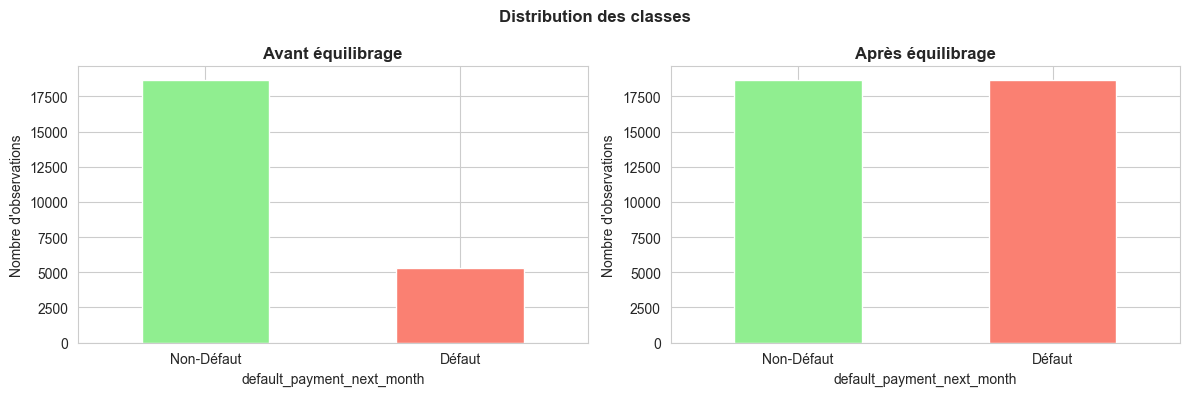

In [32]:
plot_class_distribution(
    y_train,
    y_res
)

### **1.b Appliquer les modeles avec balancement smote**

In [34]:
#results_comparison = 
desc = 'Sans Reduction Dim  avec Balancement'
results_comparison_sansReduction_avecBalancement = run_models(X_res, y_res, X_test, y_test,desc)

1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Sans Reduction Dim  avec Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.657,0.350,0.645,0.454,0.717
Decision Tree,0.762,0.466,0.530,0.496,0.712
k-NN,0.654,0.343,0.612,0.439,0.682
Random Forest,0.787,0.519,0.525,0.522,0.765



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.765
--------------------------------------------------------------------------------


### **1.c Appliquer les modeles sans balancement SMOTE**

In [35]:

desc = 'Sans Reduction Dim sans Balancement'

results_comparison_sansReduction_sansBalancement = run_models(X_train, y_train, X_test, y_test,desc)


1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Sans Reduction Dim sans Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.671,0.362,0.644,0.464,0.715
Decision Tree,0.727,0.420,0.612,0.498,0.732
k-NN,0.792,0.544,0.368,0.439,0.705
Random Forest,0.801,0.554,0.517,0.535,0.771



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.771
--------------------------------------------------------------------------------


## **2. Entrainement des models avec reduction des dimensions PCA**

In [36]:
from sklearn.decomposition import PCA
 
pca = PCA()
X_pca = pca.fit_transform(X)


- ANALYSE DE LA VARIANCE :
 Variance PC1 ................. : 31.5%
 Variance PC2 ................. : 19.9%
 Variance cumulée 2PC ......... : 51.5%
 Nombre de composantes pour 90% : 12


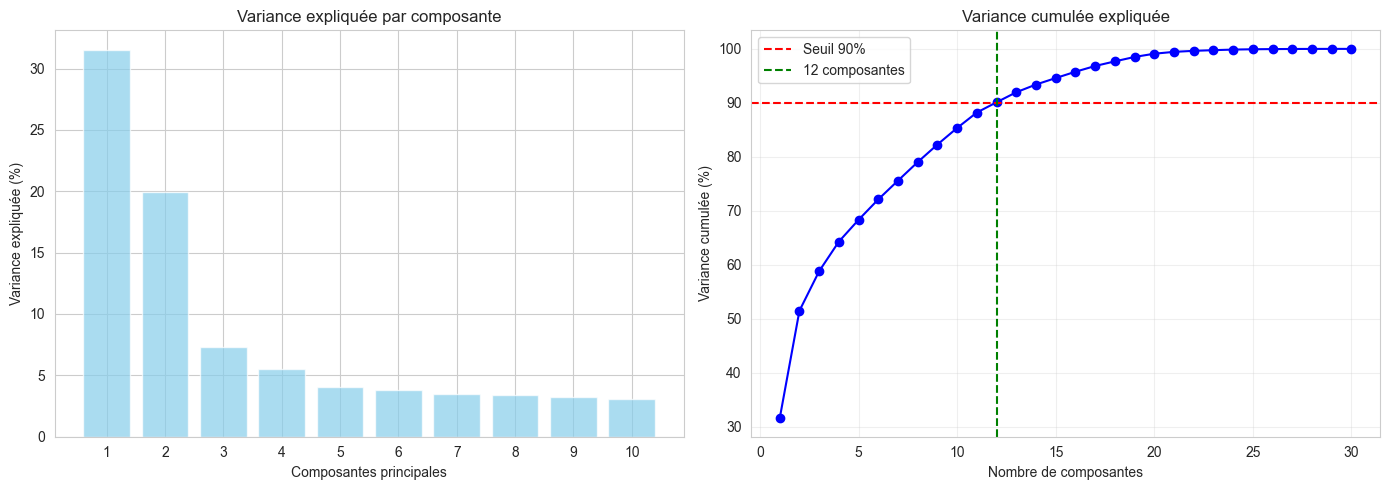

In [37]:

# 4.2 Variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1

print("- ANALYSE DE LA VARIANCE :")
print(f" Variance PC1 ................. : {explained_variance[0]*100:.1f}%")
print(f" Variance PC2 ................. : {explained_variance[1]*100:.1f}%")
print(f" Variance cumulée 2PC ......... : {(explained_variance[0]+explained_variance[1])*100:.1f}%")
print(f" Nombre de composantes pour 90% : {n_components_90}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance individuelle
axes[0].bar(range(1, 11), explained_variance[:10] * 100, alpha=0.7, color='skyblue')
axes[0].set_xlabel('Composantes principales')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Variance expliquée par composante')
axes[0].set_xticks(range(1, 11))

# Variance cumulée
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'bo-')
axes[1].axhline(y=90, color='r', linestyle='--', label='Seuil 90%')
axes[1].axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} composantes')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée expliquée')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### **2.a Application PCA pour 12 composantes**

In [38]:
# Appliquer PCA
pca = PCA(n_components=12)
X_pca_12 = pca.fit_transform(X)


### **2.b  Application du balancement SMOTE**

In [39]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca, X_res, y_res = prepare_balanced_data(
    X_pca_12,y,
    test_size=0.2,
    random_state=42,
    method='smote'   # options: 'smote', 'undersample', 'both', 'none'
)


Préparation des données

Dimensions: X=(30000, 12), y=(30000,)
Classe 0: 23364 | Classe 1: 6636

---------------------------------------------------

Train: 24000 | Test: 6000

---------------------------------------------------
Application SMOTE 

---------------------------------------------------


,Métrique,Avant,Après
0,Observations,"24,000","37,382"
1,Classe 0,"18,691","18,691"
2,Classe 1,"5,309","18,691"
3,Ratio,3.52:1,1.00:1


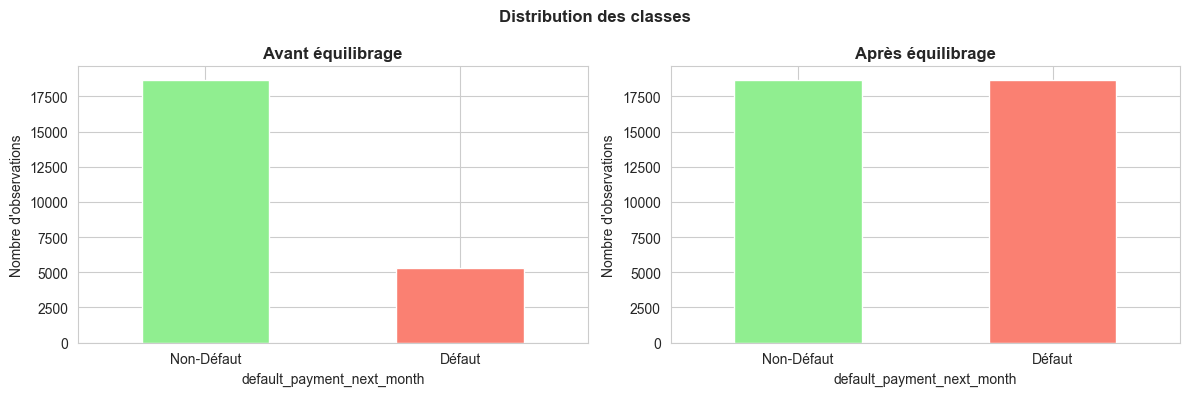

In [40]:
plot_class_distribution(
    y_train_pca,
    y_res
)

### **2.c Appliquer les modeles Avec Balancement SMOTE**

In [41]:
#-------- Execution du model

desc = 'Avec Reduction Dim  PCA(12) avec Balancement'

results_comparison_ReductionPCA_avecBalancement = run_models(X_res, y_res, X_test_pca, y_test_pca,desc)



1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Avec Reduction Dim  PCA(12) avec Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.660,0.350,0.625,0.449,0.707
Decision Tree,0.697,0.384,0.614,0.472,0.705
k-NN,0.667,0.352,0.601,0.444,0.682
Random Forest,0.768,0.477,0.534,0.504,0.754



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.754
--------------------------------------------------------------------------------


### **2.d Appliquer les modeles sans Balancement SMOTE**

In [42]:

#X_train_pca, X_test_pca, y_train_pca, y_test_pca, X_res, y_res 

desc = 'Avec Reduction Dim  PCA(12) sans Balancement'

results_comparison_ReductionPCA_sansBalancement = run_models(X_train_pca, y_train_pca, X_test_pca, y_test_pca,desc)


1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Avec Reduction Dim  PCA(12) sans Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.671,0.358,0.614,0.452,0.705
Decision Tree,0.736,0.427,0.573,0.489,0.709
k-NN,0.791,0.544,0.352,0.427,0.700
Random Forest,0.795,0.545,0.453,0.495,0.757



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.757
--------------------------------------------------------------------------------


## **3. Entrainement des models avec reduction des dimensions TSNE**

### **3.a Application TSNE**

In [43]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

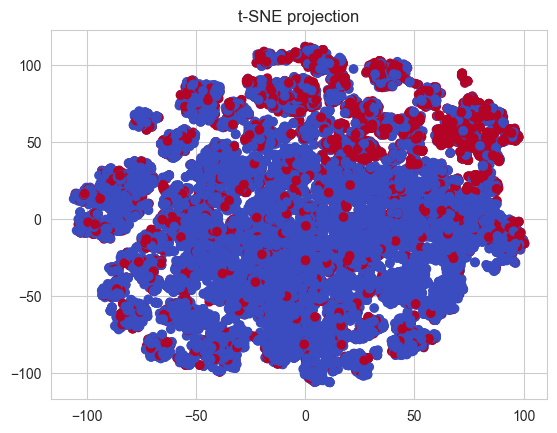

In [44]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("t-SNE projection")
plt.show()

In [45]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, X_res, y_res = prepare_balanced_data(
    X_tsne,y,
    test_size=0.2,
    random_state=42,
    method='smote'   # options: 'smote', 'undersample', 'both', 'none'
)


Préparation des données

Dimensions: X=(30000, 2), y=(30000,)
Classe 0: 23364 | Classe 1: 6636

---------------------------------------------------

Train: 24000 | Test: 6000

---------------------------------------------------
Application SMOTE 

---------------------------------------------------


,Métrique,Avant,Après
0,Observations,"24,000","37,382"
1,Classe 0,"18,691","18,691"
2,Classe 1,"5,309","18,691"
3,Ratio,3.52:1,1.00:1


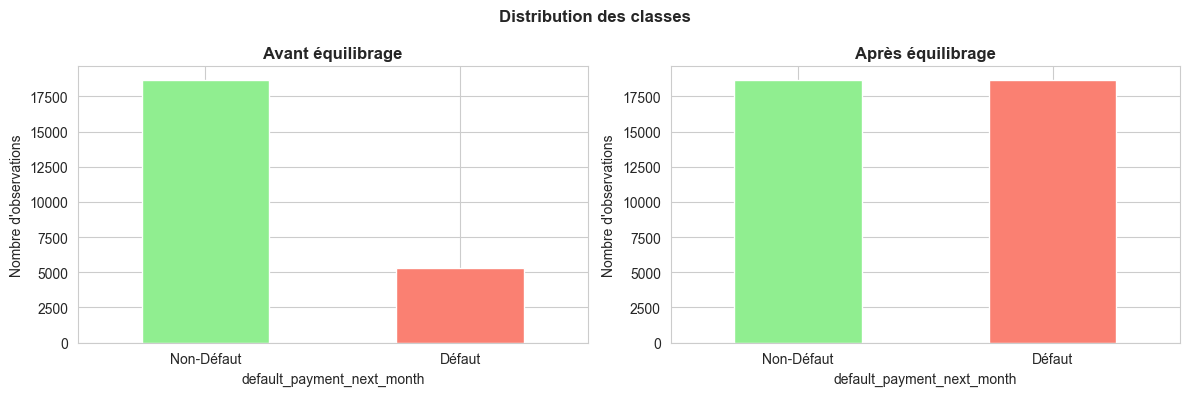

In [46]:
plot_class_distribution(
    y_train_tsne,
    y_res
)

### **3.b Appliquer les modeles Avec Balancement SMOTE**

In [47]:
#-------- Execution du model
# 

desc = 'Avec Reduction Dim  TSNE avec Balancement'

results_comparison_ReductionTSNE_avecBalancement = run_models(X_res, y_res, X_test_tsne, y_test_tsne,desc)


1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Avec Reduction Dim  TSNE avec Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.644,0.339,0.638,0.442,0.689
Decision Tree,0.741,0.430,0.524,0.473,0.696
k-NN,0.694,0.369,0.538,0.438,0.675
Random Forest,0.757,0.457,0.534,0.493,0.726



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.726
--------------------------------------------------------------------------------


### **3.c Appliquer les modeles sans Balancement SMOTE**

In [48]:
#-------- Execution du model

desc = 'Avec Reduction Dim  TSNE sans Balancement'

results_comparison_ReductionTSNE_sansBalancement = run_models(X_train_tsne, y_train_tsne, X_test_tsne, y_test_tsne,desc)

1. Logistic Regression... ✓
2. Decision Tree... ✓
3. k-NN... ✓
4. Random Forest... ✓

COMPARAISON DES MODELES Avec Reduction Dim  TSNE sans Balancement


TABLEAU RÉCAPITULATIF DES PERFORMANCES DES MODÈLES


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.644,0.338,0.638,0.442,0.689
Decision Tree,0.754,0.454,0.558,0.501,0.710
k-NN,0.766,0.464,0.360,0.406,0.687
Random Forest,0.787,0.520,0.500,0.510,0.728



--------------------------------------------------------------------------------
✓ Meilleur modèle (ROC-AUC): Random Forest  |  Score = 0.728
--------------------------------------------------------------------------------


# **4. Sommaire des résultats**

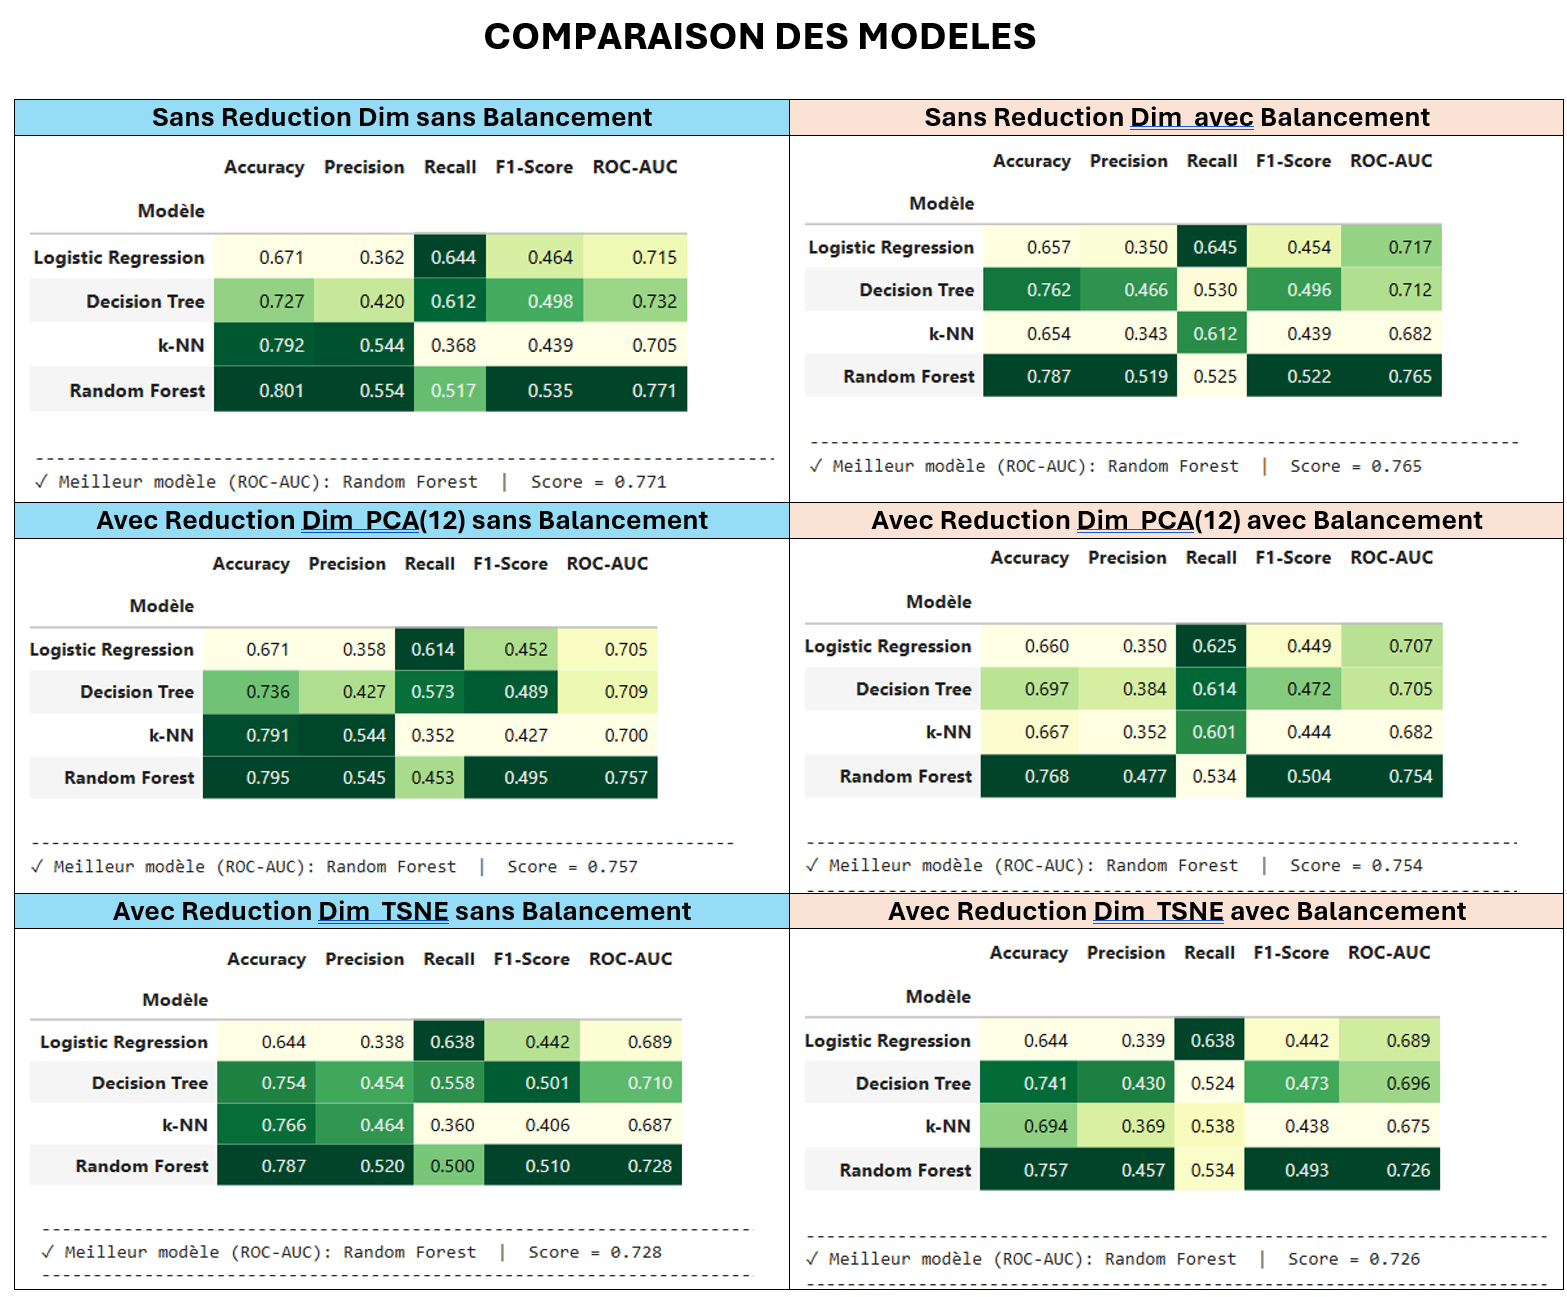


TABLEAU COMPARATIF COMPLET - TOUS LES MODÈLES ET APPROCHES (6 APPROCHES)
                       Approche              Modèle Accuracy Precision Recall F1-Score ROC-AUC
Sans Reduction Sans Balancement       Random Forest   0.8010    0.5537 0.5170   0.5347  0.7711
Sans Reduction Avec Balancement       Random Forest   0.7872    0.5186 0.5252   0.5219  0.7646
       PCA(12) Sans Balancement       Random Forest   0.7953    0.5449 0.4529   0.4947  0.7569
       PCA(12) Avec Balancement       Random Forest   0.7677    0.4774 0.5343   0.5043  0.7541
Sans Reduction Sans Balancement       Decision Tree   0.7273    0.4201 0.6119   0.4982  0.7323
          tSNE Sans Balancement       Random Forest   0.7873    0.5200 0.4996   0.5096  0.7281
          tSNE Avec Balancement       Random Forest   0.7567    0.4571 0.5343   0.4927  0.7257
Sans Reduction Avec Balancement Logistic Regression   0.6568    0.3502 0.6451   0.4540  0.7174
Sans Reduction Sans Balancement Logistic Regression   0.6708    0.3625 

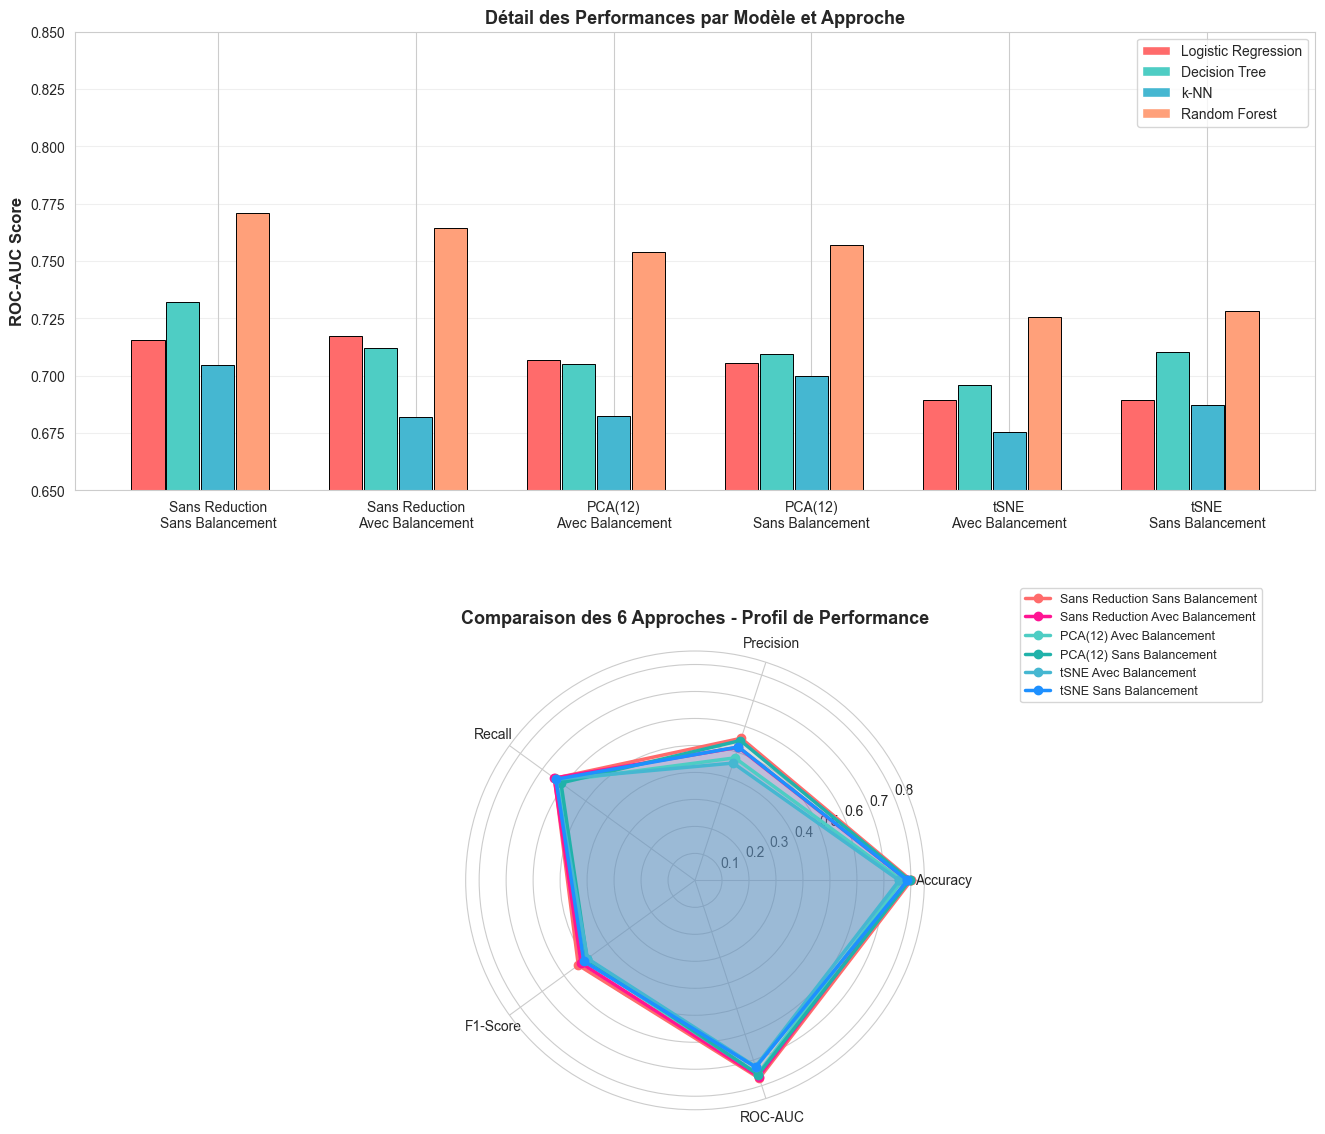


✓ Visualisations créées avec succès!


In [49]:
# ============================================================================
#  TABLEAU COMPARATIF DÉTAILLÉ
# ============================================================================
 
print("\n" + "="*140)
print("TABLEAU COMPARATIF COMPLET - TOUS LES MODÈLES ET APPROCHES (6 APPROCHES)")
print("="*140)
 
# Créer un tableau récapitulatif de tous les résultats
full_comparison = []
# Définir les 6 approches et leurs résultats
all_results = {
    'Sans Reduction\nSans Balancement': results_comparison_sansReduction_sansBalancement,
    'Sans Reduction\nAvec Balancement': results_comparison_sansReduction_avecBalancement,
    'PCA(12)\nAvec Balancement': results_comparison_ReductionPCA_avecBalancement,
    'PCA(12)\nSans Balancement': results_comparison_ReductionPCA_sansBalancement,
    'tSNE\nAvec Balancement': results_comparison_ReductionTSNE_avecBalancement,
    'tSNE\nSans Balancement': results_comparison_ReductionTSNE_sansBalancement
}
approaches = list(all_results.keys())
colors_approach = ['#FF6B6B', '#FF1493', '#4ECDC4', '#20B2AA', '#45B7D1', '#1E90FF']
 
for approach in approaches:
    results = all_results[approach]
    for _, row in results.iterrows():
        full_comparison.append({
            'Approche': approach.replace('\n', ' '),
            'Modèle': row['Modèle'],
            'Accuracy': f"{row['Accuracy']:.4f}",
            'Precision': f"{row['Precision']:.4f}",
            'Recall': f"{row['Recall']:.4f}",
            'F1-Score': f"{row['F1-Score']:.4f}",
            'ROC-AUC': f"{row['ROC-AUC']:.4f}"
        })
 
full_df = pd.DataFrame(full_comparison)
 
# Trier par ROC-AUC en ordre décroissant (meilleurs résultats en haut)
full_df_sorted = full_df.copy()
full_df_sorted['ROC-AUC_numeric'] = pd.to_numeric(full_df_sorted['ROC-AUC'])
full_df_sorted = full_df_sorted.sort_values('ROC-AUC_numeric', ascending=False).drop('ROC-AUC_numeric', axis=1)
 
print(full_df_sorted.to_string(index=False))
 
# ============================================================================
#  VISUALISATIONS (2 GRAPHIQUES L'UN APRÈS L'AUTRE)
# ============================================================================
 
fig = plt.figure(figsize=(16, 14))
 
# Couleurs pour chaque modèle
model_colors = {
    'Logistic Regression': '#FF6B6B',
    'Decision Tree': '#4ECDC4',
    'k-NN': '#45B7D1',
    'Random Forest': '#FFA07A'
}
 
# ============ VIZ 1: Détail par Modèle et Approche (6 APPROCHES) ============
ax1 = plt.subplot(2, 1, 1)
x_pos = 0
width = 0.06
colors_list = []
positions_list = []
values_list = []
labels_list = []
 
for approach_idx, approach in enumerate(approaches):
    results = all_results[approach]
    if approach_idx == 0:
        models = [m for m in model_colors.keys() if m in results['Modèle'].values]
 
    for model_idx, model in enumerate(models):
        model_data = results[results['Modèle'] == model]
        roc_score = model_data['ROC-AUC'].values[0]
 
        values_list.append(roc_score)
        positions_list.append(x_pos)
        colors_list.append(model_colors[model])
 
        if approach_idx == 0:
            labels_list.append(model)
 
        x_pos += width
 
    x_pos += 0.10  # Espacement entre les groupes d'approches
 
bars = ax1.bar(positions_list, values_list, width=width*0.95, color=colors_list, edgecolor='black', linewidth=0.7)
ax1.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax1.set_title('Détail des Performances par Modèle et Approche', fontsize=13, fontweight='bold')
 
# Corriger les positions des ticks pour les 6 approches
tick_positions = [0.12 + i*(4*width + 0.10) for i in range(len(approaches))]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(approaches, fontsize=10, rotation=0, ha='center')
 
ax1.set_ylim([0.65, 0.85])
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(handles=[plt.Rectangle((0,0),1,1.54, fc=model_colors[m]) for m in models],
          labels=models, loc='upper right', fontsize=10)
 
# ============ VIZ 2: Radar Chart - Comparaison 6 Approches ============
ax2 = plt.subplot(2, 1, 2, projection='polar')
categories = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
N = len(categories)
angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
angles += angles[:1]
 
for approach, color in zip(approaches, colors_approach):
    values = [all_results[approach][metric].max() for metric in categories]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2.5, label=approach.replace('\n', ' '), color=color)
    ax2.fill(angles, values, alpha=0.15, color=color)
 
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0, 0.85)
ax2.set_title('Comparaison des 6 Approches - Profil de Performance', fontsize=13, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.75, 1.15), fontsize=9)
ax2.grid(True)
 
plt.subplots_adjust(hspace=0.35)
plt.show()
 
print("\n✓ Visualisations créées avec succès!")

###  Classement Final des Approches
 - **Sans Réduction Sans SMOTE** (**ROC-AUC: 0.771**) -  MEILLEUR
 
###  Insights Clés
 
#### 1. **Impact du SMOTE**
- **Sans SMOTE**: score légèrement supérieur (0.7711)
- **Avec SMOTE**: score légèrement inférieur (0.7654)
- Différence: -0.57% (surprenant, le SMOTE ne donne pas d'amélioration)
 
#### 2. **Impact de la Réduction Dimensionnelle**
- **PCA (12 composantes)**: perte de 1.7% en performance
- **tSNE (2 dimensions)**: perte significative de 4.3% en performance
- **Verdict**: La réduction dimensionnelle n'améliore pas les résultats
 
#### 3. **Dominance de Random Forest**
- Tous les meilleurs résultats sont obtenus avec **Random Forest**
- Performance: consistante à ~77% ROC-AUC
- Avantage: robustesse et équilibre Precision-Recall
 
###  Recommandations
 
** Approche Recommandée:**
- **Modèle**: Random Forest
- **Configuration**: Sans réduction dimensionnelle, sans SMOTE
- **Performance**: ROC-AUC = 0.7711, Accuracy = 0.8010
- **Raison**: Meilleure performance globale, pas de surcoût computationnel
 
** Notes:**
- Le dataset semble bien équilibré après preprocessing
- Les features originales contiennent l'information nécessaire

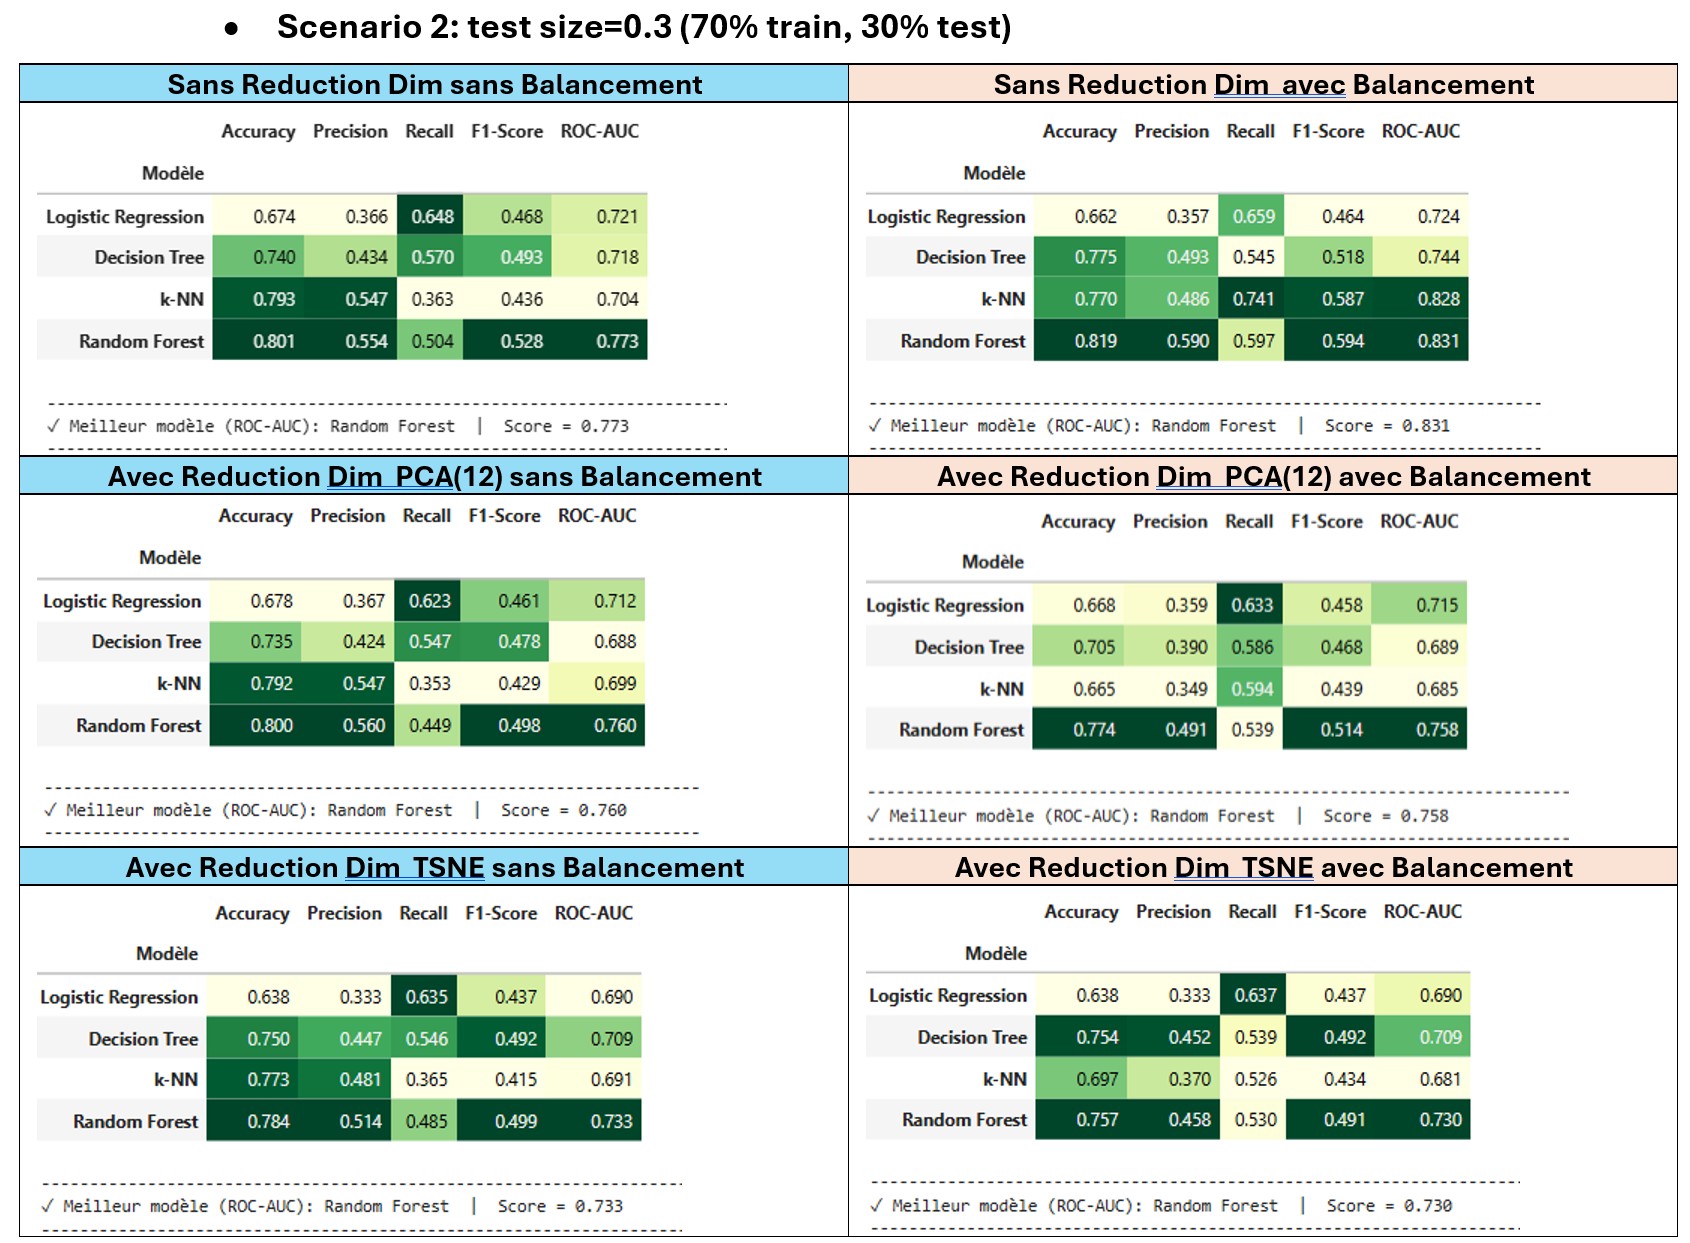

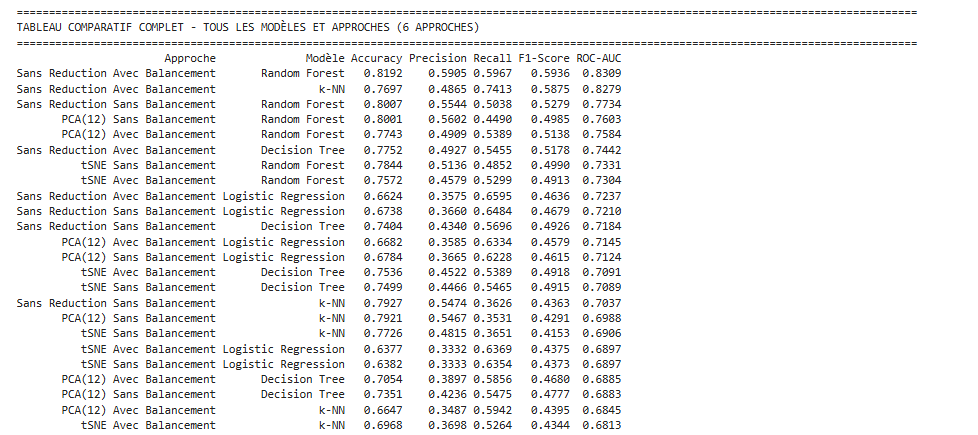

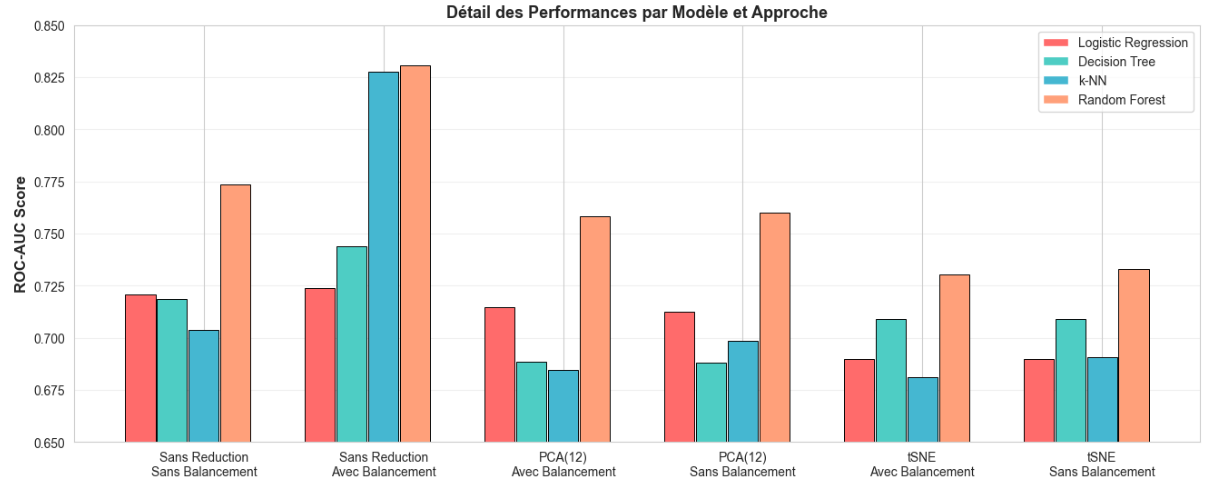

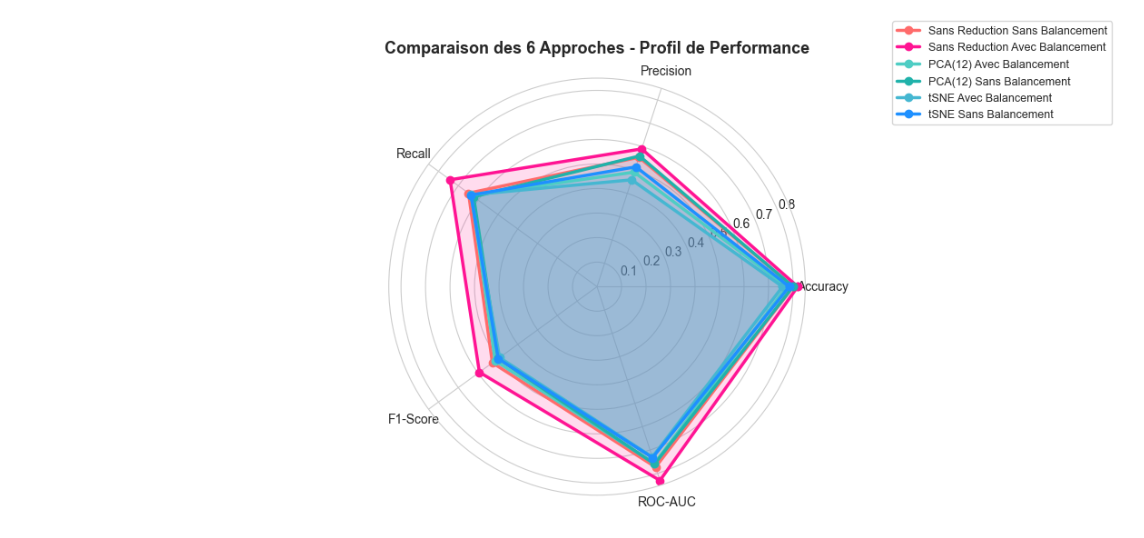

## Interprétation sénario 2

###  Classement Final des Approches sénario 2
  - **Sans Réduction Avec SMOTE** (**ROC-AUC: 0.8309**) -  MEILLEUR
   
### 1 **Variation Statistique (Variance)**
 
**Scenario 1: test_size=0.2 (80% train, 20% test)**
- Train: 24,000 observations
- Test: 6,000 observations
- Petit ensemble de test → **Résultats peu fiables** (haute variance)
- Le modèle SANS SMOTE peut "sembler" meilleur par chance statistique
 
**Scenario 2: test_size=0.3 (70% train, 30% test)**
- Train: 21,000 observations  
- Test: 9,000 observations
- Plus grand ensemble de test → **Résultats plus stables** (basse variance)
- Le vrai bénéfice du SMOTE devient visible
 
### 2 **Qualité de la Validation**
 
Avec 30% de test:
- Plus d'exemples de classe minoritaire (9,000 × 22% = ~2,000 défauts)
- Meilleure estimation de la vraie performance
- Moins d'overfitting sur les résultats de test
 
### 3 **Efficacité du Balancement**
 
**Pourquoi SMOTE aide MAINTENANT?**
- Avec 70% train (21,000 obs): assez de données pour SMOTE de créer des exemples valides
- Le modèle apprend mieux les patterns de classe minoritaire
- Meilleure **Recall** et **F1-Score** pour détecter les défauts
 
---
 